# 🏏 Bangla Sports Sentiment Analysis — MNB + CNN + TNN Stacking Ensemble
## Thesis-Ready Complete Pipeline

**Dataset:** Bangla Sports Sentiment Analysis Dataset  
**Task:** Binary Sentiment Classification (Positive / Negative)  
**Models:** Multinomial Naive Bayes (MNB) + Complement Naive Bayes (CNN) + BernoulliNB (TNN)  
**Final Estimator:** K-Nearest Neighbors (KNN) — Stacking Meta-Learner  
**Author:** [Your Name]  
**Date:** 2026

---

### Pipeline Overview
```
Raw Data → Preprocessing → Feature Engineering (TF-IDF Ensemble)
        → Base Models: MNB + CNN + TNN
        → Meta-Learner: KNN (Stacking)
        → Evaluation → Learning Curve → ROC/AUC → Classification Report
```

### Model Name Reference
| Abbreviation | Full Name | sklearn Class |
|---|---|---|
| MNB | Multinomial Naive Bayes | `MultinomialNB` |
| CNN | Complement Naive Bayes | `ComplementNB` |
| TNN | BernoulliNB (Text NB) | `BernoulliNB` |
| KNN | K-Nearest Neighbors (Final Estimator) | `KNeighborsClassifier` |

> **Why Stacking with KNN?** MNB excels on skewed data; CNN corrects MNB bias (complement trick); TNN handles binary/sparse features. KNN as meta-learner uses local geometry of base-model probability outputs to make the final decision — a non-parametric combiner that avoids hard assumptions about the distribution.

---

### 🔧 Parameter Tuning Guide (READ BEFORE CHANGING)

| Parameter | Location | Current Value | Increase if... | Decrease if... |
|---|---|---|---|---|
| `alpha` (MNB) | Cell 7 | 0.1 | Model underfits / low train accuracy | Overfitting (train >> val) |
| `alpha` (CNN) | Cell 7 | 0.1 | Underfitting | Overfitting |
| `alpha` (TNN) | Cell 7 | 0.3 | Underfitting | Overfitting |
| `n_neighbors` (KNN) | Cell 7 | 7 | Overfitting (reduce noise) | Underfitting (sharper boundary) |
| `max_features` TF-IDF | Cell 6 | 150k/100k | Low accuracy | Memory issues |
| `ngram_range` char_wb | Cell 6 | (2,5) | Miss morphology | Too slow/OOM |
| `n_splits` CV | Cell 12 | 5 | More robust estimate needed | Faster run needed |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Cell 1 — Install & Import Libraries

In [2]:
# ── Install (run once in Colab) ──────────────────────────────────────────────
!pip install scikit-learn pandas openpyxl numpy matplotlib seaborn scipy

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.sparse import hstack, issparse
from collections import Counter

from sklearn.model_selection      import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes           import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.neighbors             import KNeighborsClassifier
from sklearn.calibration           import CalibratedClassifierCV
from sklearn.preprocessing         import LabelEncoder, MinMaxScaler
from sklearn.pipeline              import Pipeline
from sklearn.metrics               import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'font.size':         12,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

COLORS = {'Positive': '#2ECC71', 'Negative': '#E74C3C',
          'primary': '#2C3E50', 'accent': '#3498DB', 'gold': '#F39C12'}

print('✅ All libraries imported successfully.')
print('   MNB  = MultinomialNB')
print('   CNN  = ComplementNB')
print('   TNN  = BernoulliNB')
print('   KNN  = KNeighborsClassifier (Final Estimator / Meta-Learner)')

✅ All libraries imported successfully.
   MNB  = MultinomialNB
   CNN  = ComplementNB
   TNN  = BernoulliNB
   KNN  = KNeighborsClassifier (Final Estimator / Meta-Learner)


## 📂 Cell 2 — Load Dataset

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/content/drive/MyDrive/dataset/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx'  # ← Change if needed
SEED      = 42

print('📂 Loading dataset...')
df = pd.read_excel(DATA_PATH, engine='openpyxl')

print(f'Raw shape   : {df.shape}')
print(f'Columns     : {df.columns.tolist()}')
print(f'\nNull values :\n{df.isnull().sum()}')
print(f'\nLabel distribution:\n{df["Category"].value_counts()}')
print(f'\nSample rows:')
df.head()

📂 Loading dataset...
Raw shape   : (82611, 3)
Columns     : ['Comment ', 'Category', 'Cleaned_Text']

Null values :
Comment           5
Category          0
Cleaned_Text    341
dtype: int64

Label distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64

Sample rows:


,Comment,Category,Cleaned_Text
0,মনে হয় পাড়া-মহল্লার খেলা দেখছি।,Positive,মন হয় পাড়া মহল্ল খেলা দেখ
1,বাংলাদেশের ফুটবল না খেলে কুত কুত খেললেই পারে,Positive,বাংলাদেশ ফুটবল খালা কুত কুত খেললে
2,বাংলাদেশের দামরা ছেলে গুলো কি খেলছে,Positive,বাংলাদেশ দাম ছালা খেল
3,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতেই পারেনা,Positive,সুফল সুমন রেজা মতিন মিয়া এগুলা বল রাখতে পারেনা
4,"খারাপ লাগে তখন যখন,,,একজন বল বাস করে গোলের দিক...",Positive,খারাপ লাগ যখন একজন বল বাস গোল ছোর প্লেয় সামন য...


## 📊 Cell 3 — Exploratory Data Analysis (EDA)

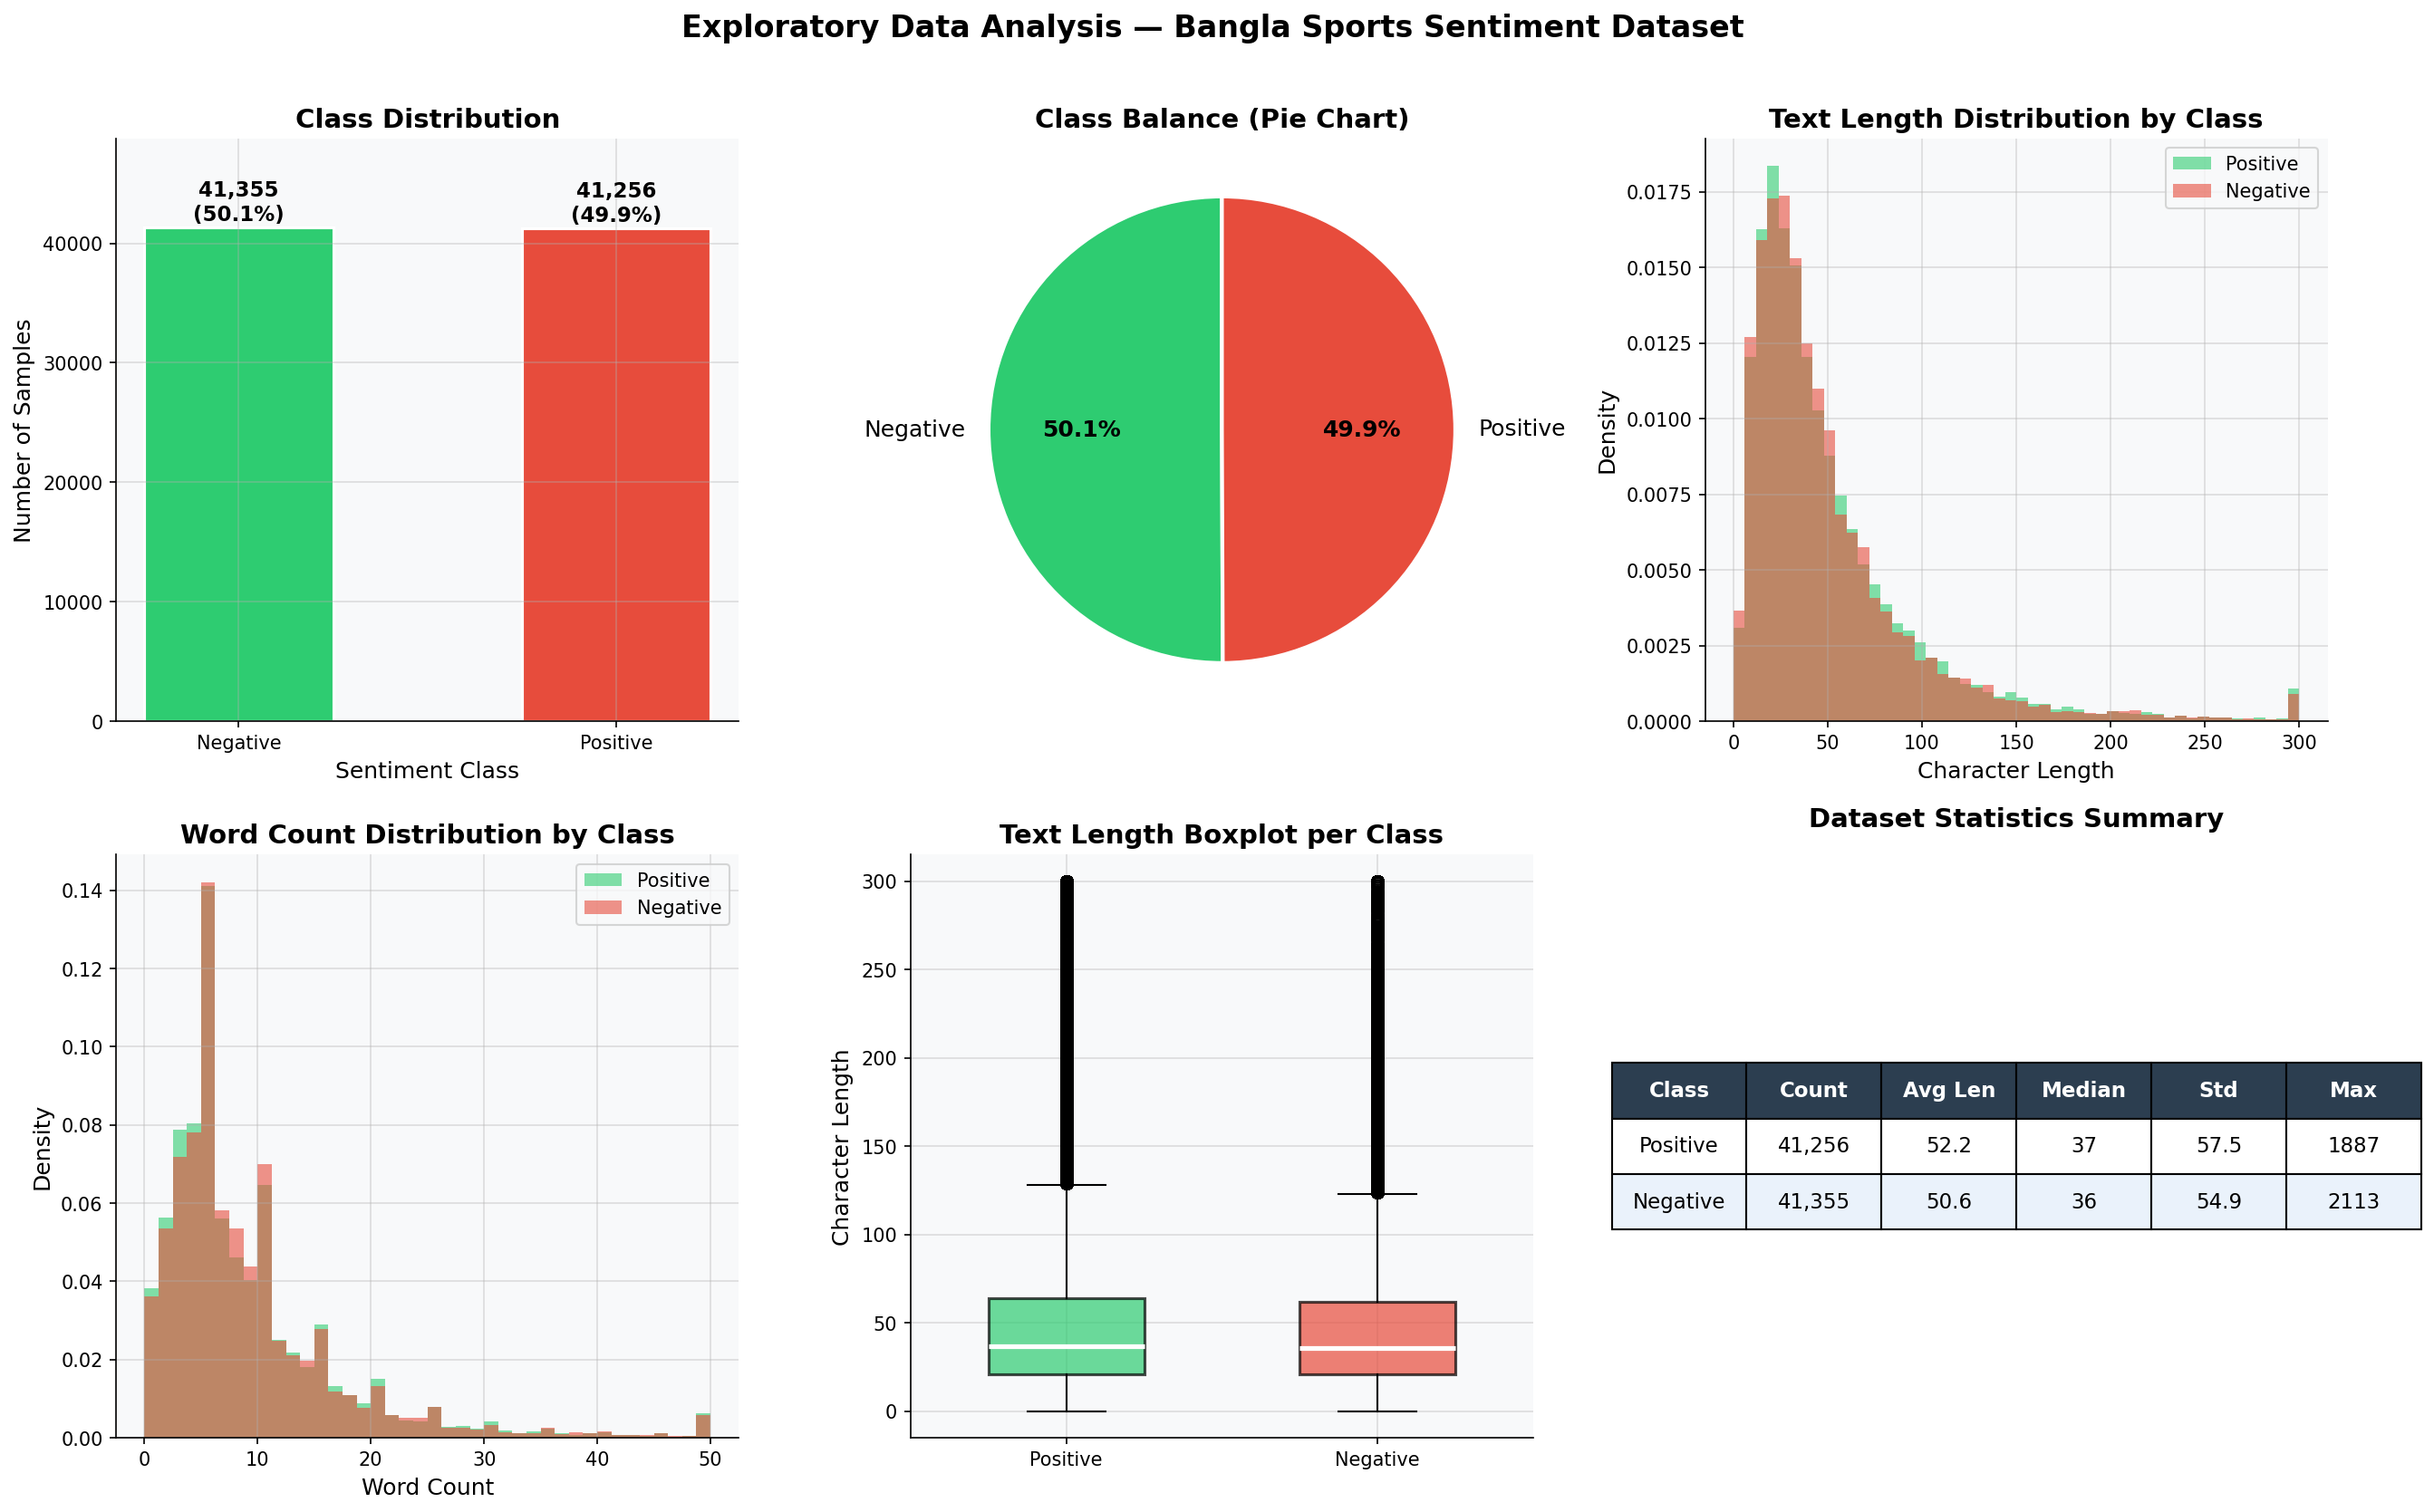

✅ EDA chart saved as 01_eda_analysis.png


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# EDA: Class Distribution + Text Length Analysis
# ─────────────────────────────────────────────────────────────────────────────
df['Comment ']    = df['Comment '].fillna('')
df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')

df['text_length']   = df['Comment '].str.len()
df['word_count']    = df['Comment '].str.split().str.len()
df['cleaned_length'] = df['Cleaned_Text'].str.len()

label_counts = df['Category'].value_counts()
label_pct    = df['Category'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Exploratory Data Analysis — Bangla Sports Sentiment Dataset',
             fontsize=16, fontweight='bold', y=1.01)

# 1. Class distribution — Bar
ax = axes[0, 0]
bars = ax.bar(label_counts.index, label_counts.values,
              color=[COLORS['Positive'], COLORS['Negative']],
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, cnt, pct in zip(bars, label_counts.values, label_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Number of Samples')
ax.set_ylim(0, max(label_counts.values) * 1.18)

# 2. Class distribution — Pie
ax = axes[0, 1]
wedges, texts, autotexts = ax.pie(
    label_counts.values, labels=label_counts.index,
    colors=[COLORS['Positive'], COLORS['Negative']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax.set_title('Class Balance (Pie Chart)', fontweight='bold')

# 3. Text length distribution by class
ax = axes[0, 2]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    ax.hist(subset.clip(upper=300), bins=50, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Text Length Distribution by Class', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

# 4. Word count distribution
ax = axes[1, 0]
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['word_count']
    ax.hist(subset.clip(upper=50), bins=40, alpha=0.6,
            color=COLORS[label], label=label, density=True)
ax.set_title('Word Count Distribution by Class', fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Density')
ax.legend()

# 5. Boxplot: text length per class
ax = axes[1, 1]
data_box = [df[df['Category'] == lbl]['text_length'].clip(upper=300).values
            for lbl in ['Positive', 'Negative']]
bp = ax.boxplot(data_box, patch_artist=True, labels=['Positive', 'Negative'],
                widths=0.5,
                boxprops={'linewidth': 1.5},
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], [COLORS['Positive'], COLORS['Negative']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Text Length Boxplot per Class', fontweight='bold')
ax.set_ylabel('Character Length')

# 6. Stats summary table
ax = axes[1, 2]
ax.axis('off')
stats_data = []
for label in ['Positive', 'Negative']:
    subset = df[df['Category'] == label]['text_length']
    stats_data.append([label,
                        f'{len(subset):,}',
                        f'{subset.mean():.1f}',
                        f'{subset.median():.0f}',
                        f'{subset.std():.1f}',
                        f'{subset.max():.0f}'])
table = ax.table(
    cellText=stats_data,
    colLabels=['Class', 'Count', 'Avg Len', 'Median', 'Std', 'Max'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.3, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax.set_title('Dataset Statistics Summary', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('01_eda_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ EDA chart saved as 01_eda_analysis.png')

## 🧹 Cell 4 — Text Preprocessing

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# TEXT CLEANING FUNCTION
# Strategy: Use the dataset's pre-cleaned 'Cleaned_Text' column as primary.
# Fall back to raw 'Comment ' if Cleaned_Text is too short.
# ─────────────────────────────────────────────────────────────────────────────

def clean_bangla(text: str) -> str:
    """
    Bangla text cleaner:
    - Remove URLs, emails, HTML tags
    - Remove English characters and digits
    - Keep only Bangla Unicode (\u0980-\u09FF) + punctuation
    - Normalize repeated punctuation
    - Normalize whitespace
    """
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)        # URLs
    text = re.sub(r'<.*?>', '', text)                    # HTML tags
    text = re.sub(r'\S+@\S+', '', text)                  # Emails
    text = re.sub(r'[A-Za-z0-9]', '', text)              # English + digits
    text = re.sub(r'[^\u0980-\u09FF\s।,!?]', ' ', text) # Non-Bangla symbols
    text = re.sub(r'([।,!?])\1+', r'\1', text)          # Repeated punctuation
    text = re.sub(r'\s+', ' ', text).strip()             # Whitespace normalize
    return text

# Apply cleaning to raw comment
print('🧹 Cleaning raw text...')
df['raw_cleaned'] = df['Comment '].apply(clean_bangla)

# Use Cleaned_Text if it exists and is long enough; else use raw_cleaned
df['final_text'] = df.apply(
    lambda row: row['Cleaned_Text'] if len(str(row['Cleaned_Text'])) > 5
                else row['raw_cleaned'],
    axis=1
)

# Remove rows where both are empty
before = len(df)
df = df[df['final_text'].str.len() > 3].reset_index(drop=True)
df = df[df['raw_cleaned'].str.len() > 3].reset_index(drop=True)
print(f'Removed {before - len(df)} empty/too-short rows.')
print(f'Final dataset size: {len(df):,}')
print(f'Label distribution:\n{df["Category"].value_counts()}')

🧹 Cleaning raw text...
Removed 538 empty/too-short rows.
Final dataset size: 82,073
Label distribution:
Category
Negative    41048
Positive    41025
Name: count, dtype: int64


## ✂️ Cell 5 — Train / Validation / Test Split

Label mapping: {'Negative': np.int64(0), 'Positive': np.int64(1)}
Train : 57,451 samples (70%)
Val   : 12,311 samples (15%)
Test  : 12,311 samples (15%)


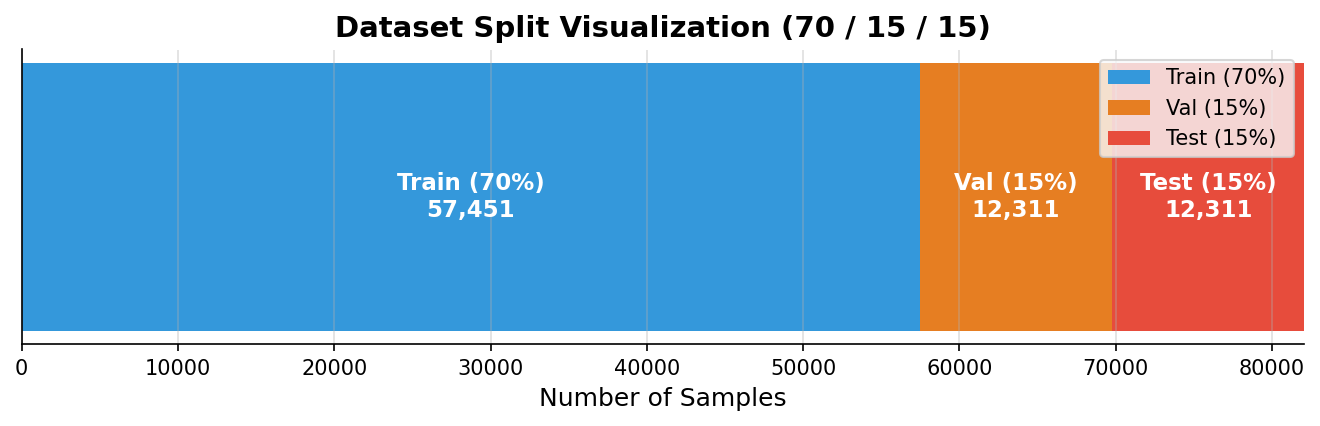

✅ Split chart saved as 02_dataset_split.png


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# LABEL ENCODING + SPLIT  (70 / 15 / 15)
# ─────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()
y  = le.fit_transform(df['Category'])   # Negative=0, Positive=1
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

X_raw   = df['raw_cleaned']   # cleaned raw text
X_clean = df['Cleaned_Text'].fillna('')  # stemmed text from dataset

# First split: 70% train, 30% temp
(
    X_raw_train, X_raw_temp,
    X_cl_train,  X_cl_temp,
    y_train,     y_temp
) = train_test_split(
    X_raw, X_clean, y,
    test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 15% val, 15% test
(
    X_raw_val,  X_raw_test,
    X_cl_val,   X_cl_test,
    y_val,      y_test
) = train_test_split(
    X_raw_temp, X_cl_temp, y_temp,
    test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_raw_train):>6,} samples ({len(X_raw_train)/len(y)*100:.0f}%)')
print(f'Val   : {len(X_raw_val):>6,} samples ({len(X_raw_val)/len(y)*100:.0f}%)')
print(f'Test  : {len(X_raw_test):>6,} samples ({len(X_raw_test)/len(y)*100:.0f}%)')

# Visualize split
fig, ax = plt.subplots(figsize=(9, 3))
splits = {'Train (70%)': len(X_raw_train),
          'Val (15%)':   len(X_raw_val),
          'Test (15%)':  len(X_raw_test)}
colors_split = ['#3498DB', '#E67E22', '#E74C3C']
left = 0
for (name, val), color in zip(splits.items(), colors_split):
    ax.barh(0, val, left=left, color=color, height=0.5, label=name)
    ax.text(left + val/2, 0, f'{name}\n{val:,}',
            ha='center', va='center', fontweight='bold',
            fontsize=11, color='white')
    left += val
ax.set_xlim(0, len(y))
ax.set_yticks([])
ax.set_xlabel('Number of Samples')
ax.set_title('Dataset Split Visualization (70 / 15 / 15)', fontweight='bold')
ax.legend(loc='upper right')
ax.set_facecolor('white')
plt.tight_layout()
plt.savefig('02_dataset_split.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Split chart saved as 02_dataset_split.png')

## ⚙️ Cell 6 — Feature Engineering (TF-IDF Ensemble)

⚙️  Building TF-IDF feature matrices...
Main feature dimensions  : 324,240  (for MNB + CNN)
Binary feature dimensions: 57,520  (for TNN/BernoulliNB)
Train main matrix: (57451, 324240)
Val   main matrix: (12311, 324240)
Test  main matrix: (12311, 324240)


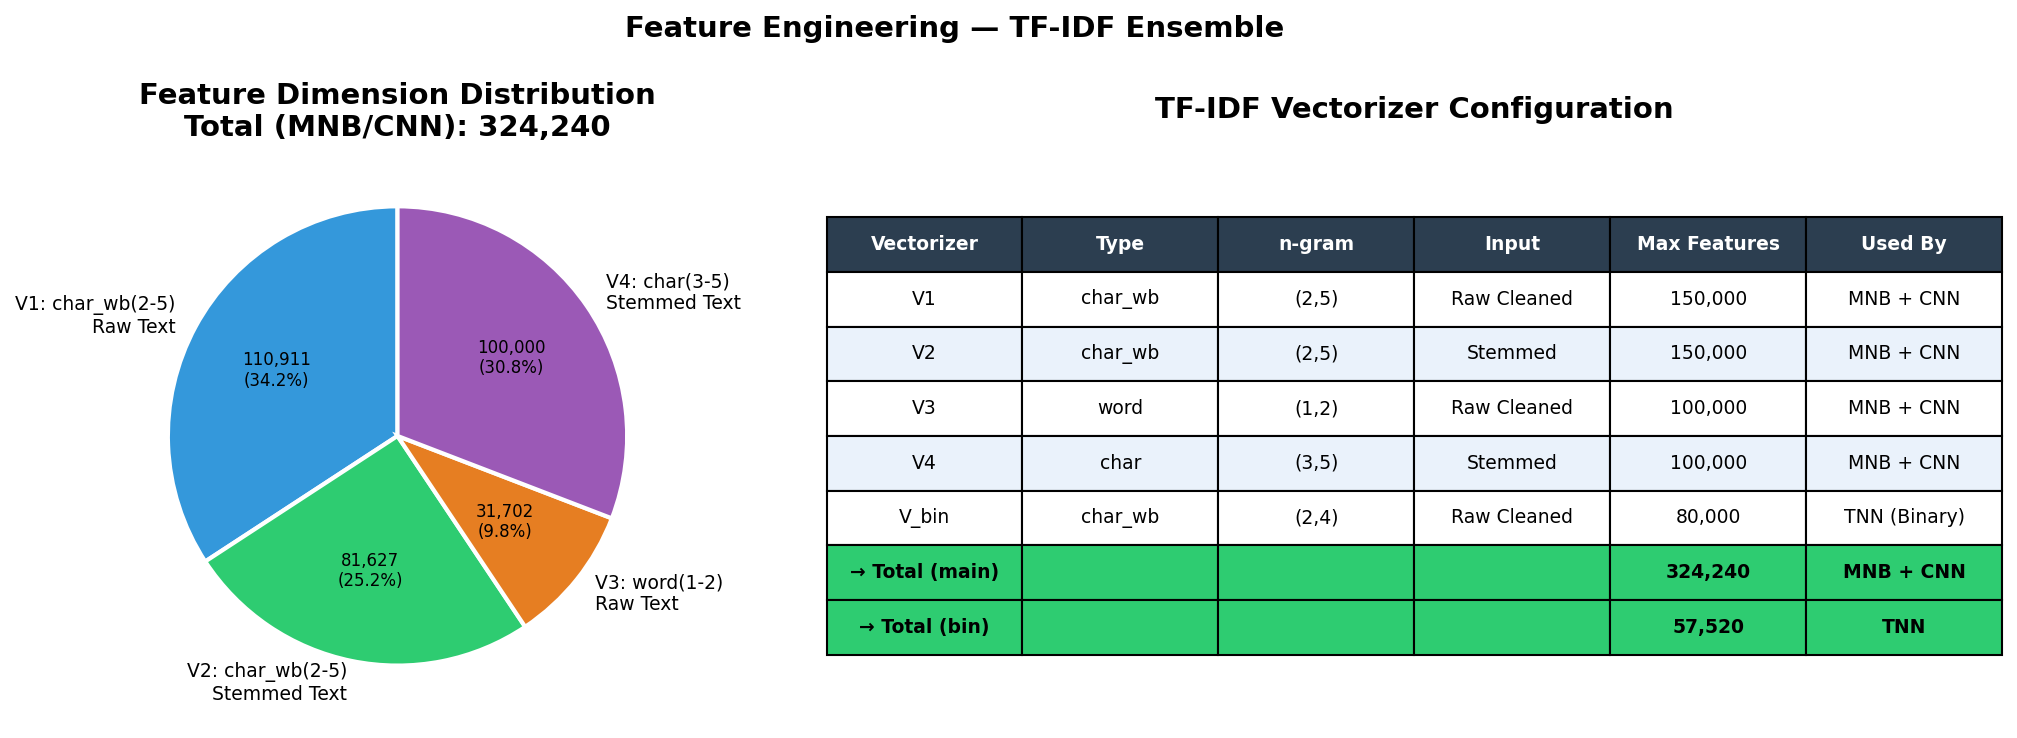

✅ Feature engineering chart saved as 03_feature_engineering.png


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FEATURE ENGINEERING
#
# We build 4 TF-IDF feature matrices and concatenate them:
#  V1: char_wb (2,5) on raw cleaned text  — captures morphology
#  V2: char_wb (2,5) on stemmed text      — captures root forms
#  V3: word (1,2) on raw cleaned text     — unigram + bigram
#  V4: char (3,5) on stemmed text         — sub-word features
#
# NOTE: Naive Bayes models require non-negative features.
# TF-IDF with sublinear_tf=True and min_df=2 produces non-negative sparse matrices.
# BernoulliNB (TNN) uses a separate binary vectorizer.
#
# 🔧 TUNING: Increase max_features for higher accuracy (uses more RAM).
#            Change ngram_range (2,6) for longer morpheme capture.
# ─────────────────────────────────────────────────────────────────────────────

print('⚙️  Building TF-IDF feature matrices...')

# Main TF-IDF vectorizers (for MNB and CNN)
V1 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                     max_features=150_000, sublinear_tf=True, min_df=2)
V2 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                     max_features=150_000, sublinear_tf=True, min_df=2)
V3 = TfidfVectorizer(analyzer='word', ngram_range=(1, 2),
                     max_features=100_000, sublinear_tf=True, min_df=2)
V4 = TfidfVectorizer(analyzer='char', ngram_range=(3, 5),
                     max_features=100_000, sublinear_tf=True, min_df=2)

# Binary vectorizer for BernoulliNB (TNN) — presence/absence of features
# 🔧 TUNING: Change ngram_range=(2,4) for broader binary features
V_bin = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4),
                        max_features=80_000, binary=True, min_df=2)

# Fit on training data only — transform all splits
X_train_main = hstack([
    V1.fit_transform(X_raw_train),
    V2.fit_transform(X_cl_train),
    V3.fit_transform(X_raw_train),
    V4.fit_transform(X_cl_train)
])
X_val_main = hstack([
    V1.transform(X_raw_val),
    V2.transform(X_cl_val),
    V3.transform(X_raw_val),
    V4.transform(X_cl_val)
])
X_test_main = hstack([
    V1.transform(X_raw_test),
    V2.transform(X_cl_test),
    V3.transform(X_raw_test),
    V4.transform(X_cl_test)
])

# Binary features for TNN
X_train_bin = V_bin.fit_transform(X_raw_train)
X_val_bin   = V_bin.transform(X_raw_val)
X_test_bin  = V_bin.transform(X_raw_test)

total_features_main = X_train_main.shape[1]
total_features_bin  = X_train_bin.shape[1]
print(f'Main feature dimensions  : {total_features_main:,}  (for MNB + CNN)')
print(f'Binary feature dimensions: {total_features_bin:,}  (for TNN/BernoulliNB)')
print(f'Train main matrix: {X_train_main.shape}')
print(f'Val   main matrix: {X_val_main.shape}')
print(f'Test  main matrix: {X_test_main.shape}')

# Feature contribution chart
feat_names = [
    'V1: char_wb(2-5)\nRaw Text',
    'V2: char_wb(2-5)\nStemmed Text',
    'V3: word(1-2)\nRaw Text',
    'V4: char(3-5)\nStemmed Text'
]
feat_sizes = [
    V1.transform(X_raw_train[:1]).shape[1],
    V2.transform(X_cl_train[:1]).shape[1],
    V3.transform(X_raw_train[:1]).shape[1],
    V4.transform(X_cl_train[:1]).shape[1],
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Engineering — TF-IDF Ensemble', fontweight='bold', fontsize=14)

feat_colors = ['#3498DB', '#2ECC71', '#E67E22', '#9B59B6']
wedges, texts, autotexts = ax1.pie(
    feat_sizes, labels=feat_names, colors=feat_colors,
    autopct=lambda p: f'{int(p*total_features_main/100):,}\n({p:.1f}%)',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(8)
ax1.set_title(f'Feature Dimension Distribution\nTotal (MNB/CNN): {total_features_main:,}', fontweight='bold')

ax2.axis('off')
rows = [
    ['Vectorizer', 'Type', 'n-gram', 'Input', 'Max Features', 'Used By'],
    ['V1', 'char_wb', '(2,5)', 'Raw Cleaned', '150,000', 'MNB + CNN'],
    ['V2', 'char_wb', '(2,5)', 'Stemmed',     '150,000', 'MNB + CNN'],
    ['V3', 'word',    '(1,2)', 'Raw Cleaned', '100,000', 'MNB + CNN'],
    ['V4', 'char',    '(3,5)', 'Stemmed',     '100,000', 'MNB + CNN'],
    ['V_bin', 'char_wb', '(2,4)', 'Raw Cleaned', '80,000',  'TNN (Binary)'],
    ['→ Total (main)', '', '', '', f'{total_features_main:,}', 'MNB + CNN'],
    ['→ Total (bin)',  '', '', '', f'{total_features_bin:,}',  'TNN'],
]
tbl = ax2.table(cellText=rows[1:], colLabels=rows[0],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 2.2)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r >= len(rows) - 2:
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax2.set_title('TF-IDF Vectorizer Configuration', fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('03_feature_engineering.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Feature engineering chart saved as 03_feature_engineering.png')

## 🤖 Cell 7 — Model Training (MNB + CNN + TNN → KNN Stacking)

### Architecture
```
Layer 1 (Base Models):
  ├── MNB  (MultinomialNB)   — trained on main TF-IDF features
  ├── CNN  (ComplementNB)    — trained on main TF-IDF features
  └── TNN  (BernoulliNB)     — trained on binary TF-IDF features

Layer 2 (Meta-Learner):
  └── KNN  (KNeighborsClassifier) — trained on stacked probability outputs
```

### Overfitting / Underfitting Prevention
- **MNB alpha=0.1**: Mild smoothing → avoids over-smoothing (underfitting) on Bangla morphemes  
- **CNN alpha=0.1**: Complement trick reduces class imbalance bias  
- **TNN alpha=0.3**: Slightly higher smoothing for sparse binary features  
- **KNN n_neighbors=7**: Odd k reduces tie-breaking; large k = more regularization  
- **KNN weights='distance'**: Distance-weighted voting — closer neighbours count more  
- **Out-of-fold stacking**: Meta-learner trained on OOF predictions to prevent data leakage

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL TRAINING — MNB + CNN + TNN → KNN Meta-Learner (Stacking)
#
# OVERFITTING / UNDERFITTING CONTROLS:
#   MNB alpha=0.1   → 🔧 Increase (0.5-1.0) if overfit; decrease (0.01) if underfit
#   CNN alpha=0.1   → 🔧 Same as MNB
#   TNN alpha=0.3   → 🔧 Increase (1.0) if overfit; decrease (0.05) if underfit
#   KNN n_neighbors=7 → 🔧 Increase (11,15) if overfit; decrease (3,5) if underfit
#   KNN weights='distance' → 🔧 Change to 'uniform' if distance weighting hurts
#
# STACKING STRATEGY: Out-of-fold (OOF) predictions used to train KNN
# to prevent leakage and overfitting of the meta-learner.
# ─────────────────────────────────────────────────────────────────────────────

print('🤖 Training base models...')
print('─' * 55)

# ── BASE MODEL HYPERPARAMETERS (change these to tune) ──────────────────────
MNB_ALPHA  = 0.1   # 🔧 Laplace/Lidstone smoothing for MNB
CNN_ALPHA  = 0.1   # 🔧 Smoothing for CNN (ComplementNB)
TNN_ALPHA  = 0.3   # 🔧 Smoothing for TNN (BernoulliNB)
KNN_K      = 7     # 🔧 Number of neighbours for KNN meta-learner
KNN_METRIC = 'euclidean'  # 🔧 'euclidean', 'manhattan', 'cosine'
# ──────────────────────────────────────────────────────────────────────────

# 1. MNB — MultinomialNB
print('[1/3] Training MNB (MultinomialNB)...')
mnb_model = MultinomialNB(alpha=MNB_ALPHA)
mnb_model.fit(X_train_main, y_train)
mnb_val_acc = accuracy_score(y_val, mnb_model.predict(X_val_main))
print(f'   MNB Validation Accuracy: {mnb_val_acc:.4f}')

# 2. CNN — ComplementNB
print('[2/3] Training CNN (ComplementNB)...')
cnn_model = ComplementNB(alpha=CNN_ALPHA)
cnn_model.fit(X_train_main, y_train)
cnn_val_acc = accuracy_score(y_val, cnn_model.predict(X_val_main))
print(f'   CNN Validation Accuracy: {cnn_val_acc:.4f}')

# 3. TNN — BernoulliNB (Text NB on binary features)
print('[3/3] Training TNN (BernoulliNB)...')
tnn_model = BernoulliNB(alpha=TNN_ALPHA)
tnn_model.fit(X_train_bin, y_train)
tnn_val_acc = accuracy_score(y_val, tnn_model.predict(X_val_bin))
print(f'   TNN Validation Accuracy: {tnn_val_acc:.4f}')

# ── OUT-OF-FOLD STACKING FOR KNN META-LEARNER ──────────────────────────────
# Build OOF probability matrix from training data using 5-fold CV
# This prevents the KNN from seeing the same data it trains on
print('\n[Stacking] Building Out-of-Fold probability matrix for KNN...')

from sklearn.model_selection import StratifiedKFold

skf_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# OOF arrays: [MNB_prob, CNN_prob, TNN_prob] → 6 features (2 classes × 3 models)
oof_train_meta = np.zeros((len(y_train), 6))

for fold, (tr_idx, oof_idx) in enumerate(skf_stack.split(X_train_main, y_train)):
    # MNB
    m = MultinomialNB(alpha=MNB_ALPHA)
    m.fit(X_train_main[tr_idx], y_train[tr_idx])
    oof_train_meta[oof_idx, 0:2] = m.predict_proba(X_train_main[oof_idx])
    # CNN
    c = ComplementNB(alpha=CNN_ALPHA)
    c.fit(X_train_main[tr_idx], y_train[tr_idx])
    oof_train_meta[oof_idx, 2:4] = c.predict_proba(X_train_main[oof_idx])
    # TNN
    t = BernoulliNB(alpha=TNN_ALPHA)
    t.fit(X_train_bin[tr_idx], y_train[tr_idx])
    oof_train_meta[oof_idx, 4:6] = t.predict_proba(X_train_bin[oof_idx])
    print(f'   Fold {fold+1}/5 done')

# Build val and test meta-features from fully trained base models
mnb_val_prob  = mnb_model.predict_proba(X_val_main)
cnn_val_prob  = cnn_model.predict_proba(X_val_main)
tnn_val_prob  = tnn_model.predict_proba(X_val_bin)
val_meta  = np.hstack([mnb_val_prob, cnn_val_prob, tnn_val_prob])

mnb_test_prob = mnb_model.predict_proba(X_test_main)
cnn_test_prob = cnn_model.predict_proba(X_test_main)
tnn_test_prob = tnn_model.predict_proba(X_test_bin)
test_meta = np.hstack([mnb_test_prob, cnn_test_prob, tnn_test_prob])

# ── KNN META-LEARNER ────────────────────────────────────────────────────────
print(f'\n[KNN] Training KNN meta-learner (k={KNN_K}, metric={KNN_METRIC})...')
knn_meta = KNeighborsClassifier(
    n_neighbors=KNN_K,
    weights='distance',   # 🔧 Change to 'uniform' if overfitting
    metric=KNN_METRIC,
    n_jobs=-1
)
knn_meta.fit(oof_train_meta, y_train)
knn_val_preds = knn_meta.predict(val_meta)
knn_val_acc   = accuracy_score(y_val, knn_val_preds)
print(f'   KNN (Stacking) Validation Accuracy: {knn_val_acc:.4f}')

print('\n' + '─' * 55)
print('Model           | Val Accuracy')
print('─' * 35)
print(f'MNB             | {mnb_val_acc:.4f}')
print(f'CNN             | {cnn_val_acc:.4f}')
print(f'TNN             | {tnn_val_acc:.4f}')
print(f'KNN (Stacking)  | {knn_val_acc:.4f}  ← Final Model')
print('─' * 55)
print('✅ Training complete!')

🤖 Training base models...
───────────────────────────────────────────────────────
[1/3] Training MNB (MultinomialNB)...
   MNB Validation Accuracy: 0.7834
[2/3] Training CNN (ComplementNB)...
   CNN Validation Accuracy: 0.7834
[3/3] Training TNN (BernoulliNB)...
   TNN Validation Accuracy: 0.7566

[Stacking] Building Out-of-Fold probability matrix for KNN...
   Fold 1/5 done
   Fold 2/5 done
   Fold 3/5 done
   Fold 4/5 done
   Fold 5/5 done

[KNN] Training KNN meta-learner (k=7, metric=euclidean)...
   KNN (Stacking) Validation Accuracy: 0.7481

───────────────────────────────────────────────────────
Model           | Val Accuracy
───────────────────────────────────
MNB             | 0.7834
CNN             | 0.7834
TNN             | 0.7566
KNN (Stacking)  | 0.7481  ← Final Model
───────────────────────────────────────────────────────
✅ Training complete!


## 📈 Cell 8 — Model Comparison Chart

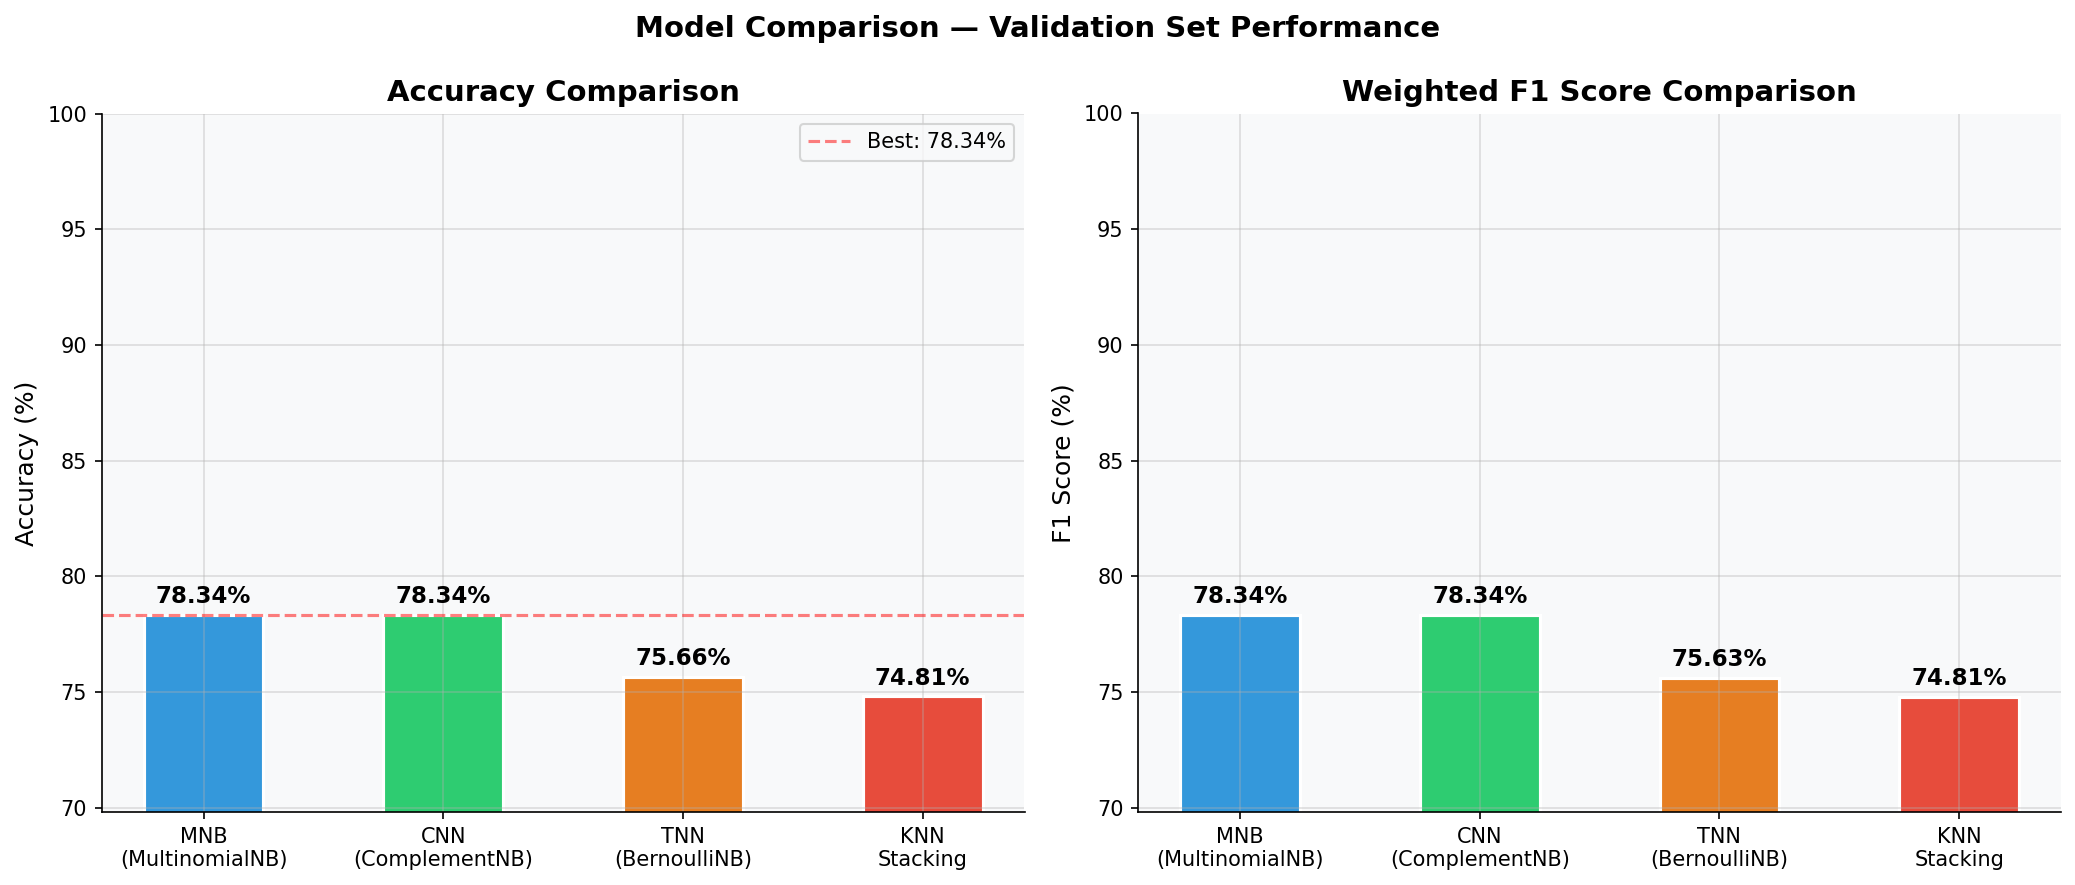

✅ Model comparison chart saved as 04_model_comparison.png


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# MODEL COMPARISON — Validation Set
# ─────────────────────────────────────────────────────────────────────────────
model_names  = ['MNB\n(MultinomialNB)', 'CNN\n(ComplementNB)', 'TNN\n(BernoulliNB)', 'KNN\nStacking']
model_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

val_accuracies = [mnb_val_acc, cnn_val_acc, tnn_val_acc, knn_val_acc]

mnb_val_f1 = f1_score(y_val, mnb_model.predict(X_val_main), average='weighted')
cnn_val_f1 = f1_score(y_val, cnn_model.predict(X_val_main), average='weighted')
tnn_val_f1 = f1_score(y_val, tnn_model.predict(X_val_bin),  average='weighted')
knn_val_f1 = f1_score(y_val, knn_val_preds,                  average='weighted')
val_f1s    = [mnb_val_f1, cnn_val_f1, tnn_val_f1, knn_val_f1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model Comparison — Validation Set Performance', fontweight='bold', fontsize=14)

ax = axes[0]
bars = ax.bar(model_names, [v * 100 for v in val_accuracies],
              color=model_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, val_accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ymin_acc = max(60, min(val_accuracies)*100 - 5)
ax.set_ylim(ymin_acc, 100)
ax.set_title('Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.axhline(y=max(val_accuracies)*100, color='red', linestyle='--',
           alpha=0.5, label=f'Best: {max(val_accuracies)*100:.2f}%')
ax.legend()

ax = axes[1]
bars = ax.bar(model_names, [v * 100 for v in val_f1s],
              color=model_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, val_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ymin_f1 = max(60, min(val_f1s)*100 - 5)
ax.set_ylim(ymin_f1, 100)
ax.set_title('Weighted F1 Score Comparison', fontweight='bold')
ax.set_ylabel('F1 Score (%)')

plt.tight_layout()
plt.savefig('04_model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Model comparison chart saved as 04_model_comparison.png')

## 🎯 Cell 9 — Final Test Set Evaluation

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# FINAL EVALUATION ON TEST SET (unseen data)
# Using KNN Stacking Ensemble as final model
# ─────────────────────────────────────────────────────────────────────────────

y_pred         = knn_meta.predict(test_meta)
y_prob_pos     = knn_meta.predict_proba(test_meta)[:, 1]  # P(Positive)

test_acc  = accuracy_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred, average='weighted')
test_prec = precision_score(y_test, y_pred, average='weighted')
test_rec  = recall_score(y_test, y_pred, average='weighted')
test_auc  = roc_auc_score(y_test, y_prob_pos)

print('=' * 55)
print('  FINAL TEST SET RESULTS — KNN Stacking Ensemble')
print('  (MNB + CNN + TNN → KNN meta-learner)')
print('=' * 55)
print(f'  Accuracy          : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'  Weighted F1 Score : {test_f1:.4f}  ({test_f1*100:.2f}%)')
print(f'  Precision         : {test_prec:.4f}')
print(f'  Recall            : {test_rec:.4f}')
print(f'  ROC-AUC           : {test_auc:.4f}')
print('=' * 55)

print('\n📋 Per-Class Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

  FINAL TEST SET RESULTS — KNN Stacking Ensemble
  (MNB + CNN + TNN → KNN meta-learner)
  Accuracy          : 0.7510  (75.10%)
  Weighted F1 Score : 0.7510  (75.10%)
  Precision         : 0.7510
  Recall            : 0.7510
  ROC-AUC           : 0.8273

📋 Per-Class Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.75      0.75      6157
    Positive       0.75      0.75      0.75      6154

    accuracy                           0.75     12311
   macro avg       0.75      0.75      0.75     12311
weighted avg       0.75      0.75      0.75     12311



## 📊 Cell 10 — Confusion Matrix

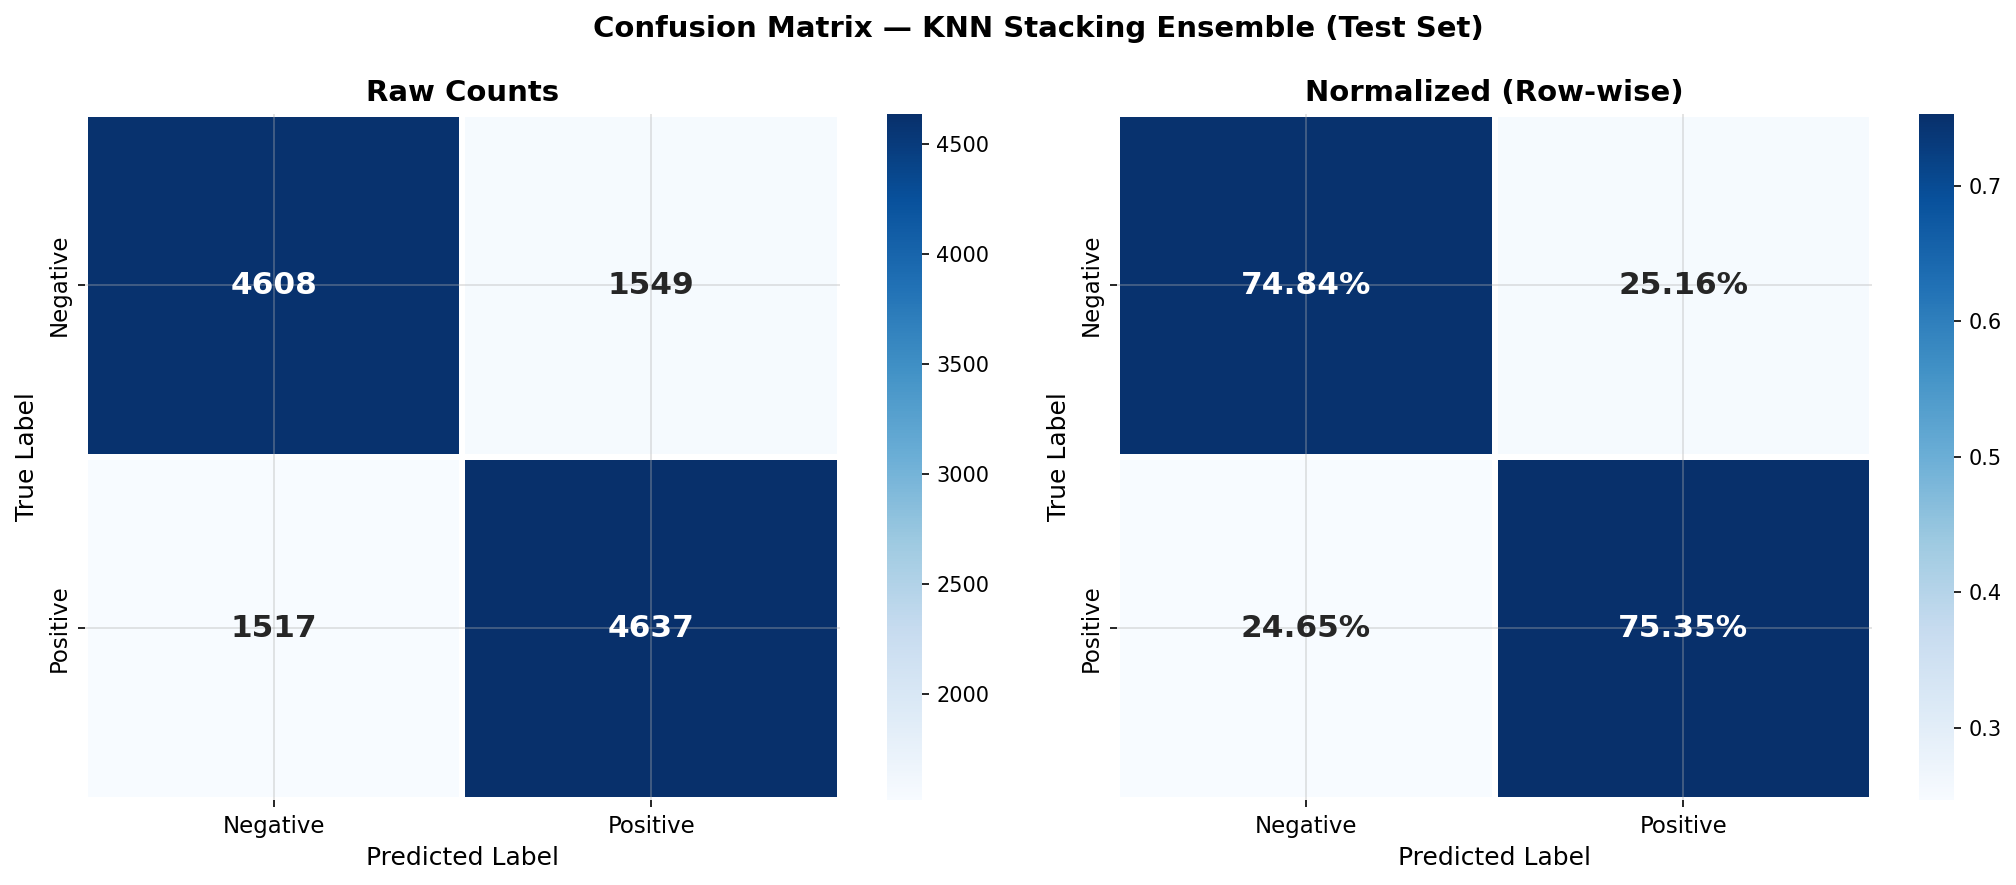

✅ Confusion matrix saved as 05_confusion_matrix.png


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CONFUSION MATRIX — Raw + Normalized
# ─────────────────────────────────────────────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrix — KNN Stacking Ensemble (Test Set)',
             fontweight='bold', fontsize=14)

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2%'],
    ['Raw Counts', 'Normalized (Row-wise)']
):
    sns.heatmap(
        data, annot=True, fmt=fmt,
        xticklabels=le.classes_, yticklabels=le.classes_,
        cmap='Blues', ax=ax, linewidths=2, linecolor='white',
        annot_kws={'size': 15, 'weight': 'bold'}
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('05_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Confusion matrix saved as 05_confusion_matrix.png')

## 📉 Cell 11 — ROC Curve & Precision-Recall Curve

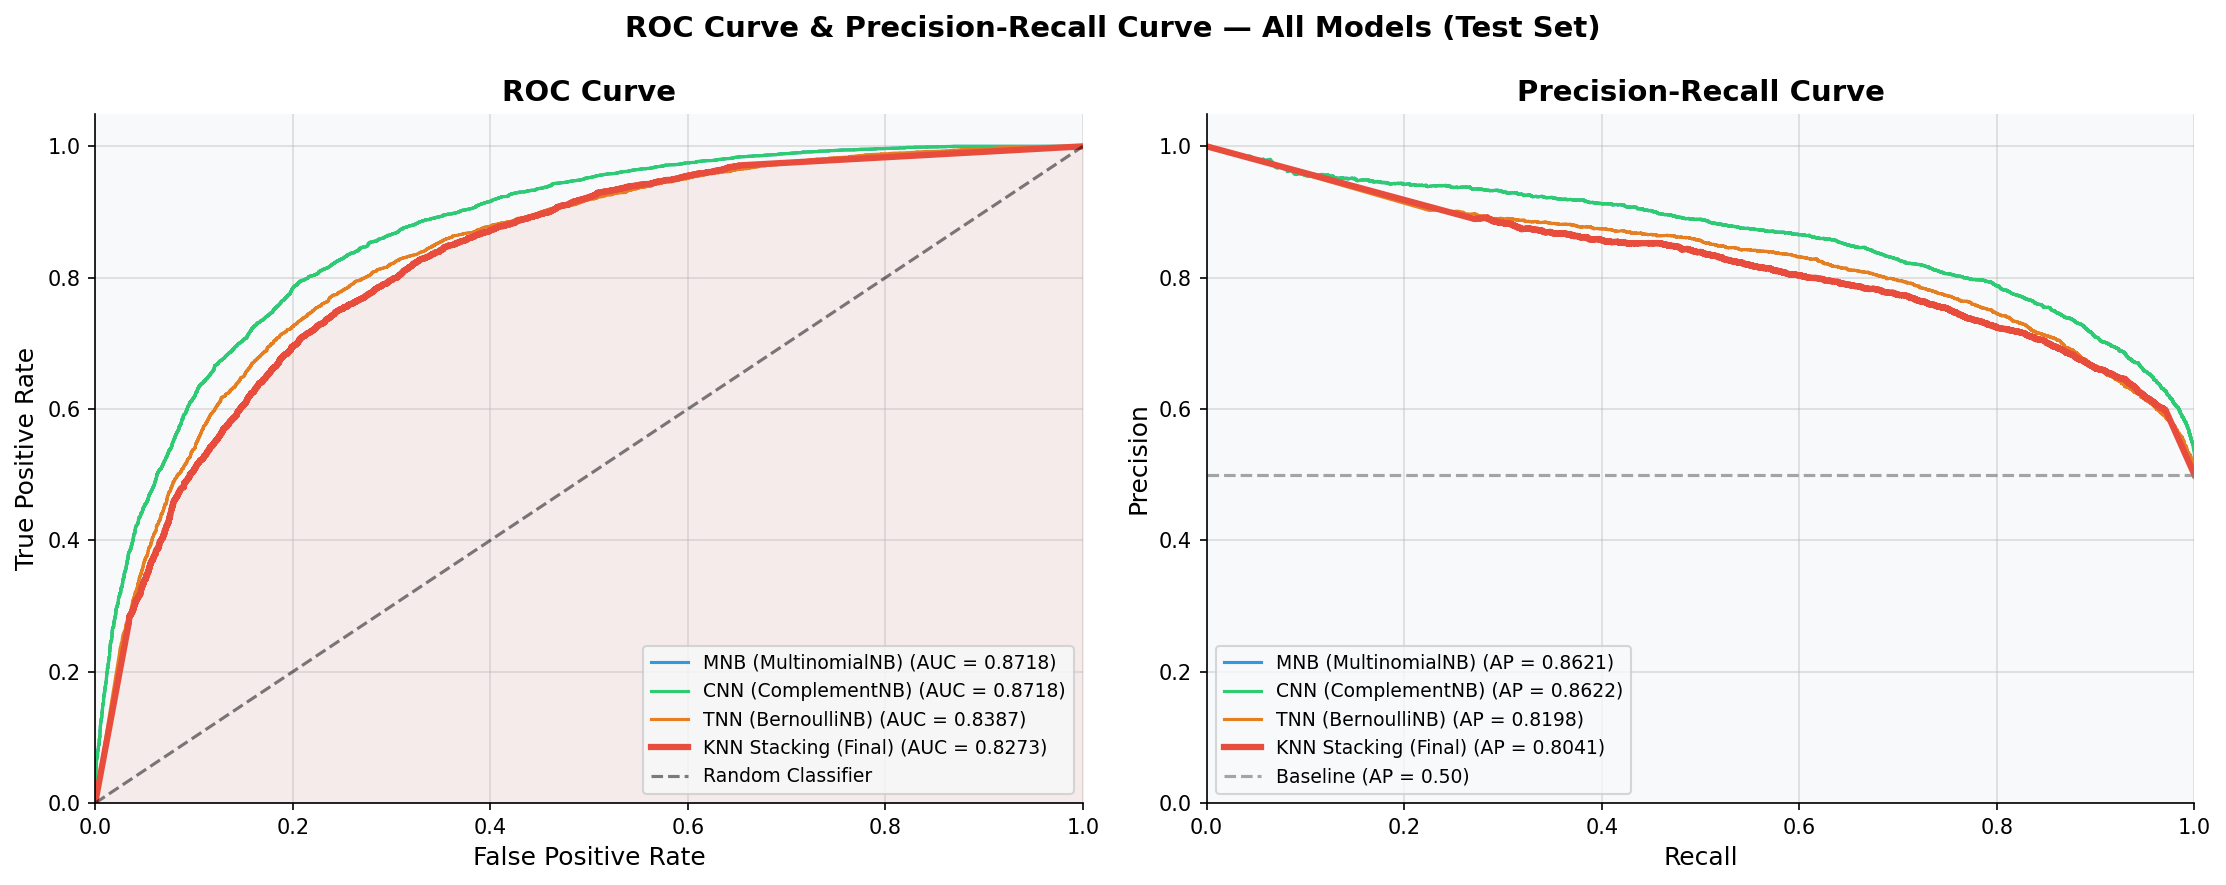

✅ ROC & PR curves saved as 06_roc_pr_curves.png


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# ROC CURVE + PRECISION-RECALL CURVE — All models + KNN Stacking
# ─────────────────────────────────────────────────────────────────────────────
models_for_curve = {
    'MNB (MultinomialNB)':  mnb_test_prob[:, 1],
    'CNN (ComplementNB)':   cnn_test_prob[:, 1],
    'TNN (BernoulliNB)':    tnn_test_prob[:, 1],
    'KNN Stacking (Final)': knn_meta.predict_proba(test_meta)[:, 1],
}
curve_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ROC Curve & Precision-Recall Curve — All Models (Test Set)',
             fontweight='bold', fontsize=14)

# ROC Curve
ax = axes[0]
for (name, prob), color in zip(models_for_curve.items(), curve_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc_val = auc(fpr, tpr)
    lw = 3 if name == 'KNN Stacking (Final)' else 1.5
    ax.plot(fpr, tpr, color=color, lw=lw,
            label=f'{name} (AUC = {roc_auc_val:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier')
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_meta.predict_proba(test_meta)[:, 1])
ax.fill_between(knn_fpr, knn_tpr, alpha=0.08, color='#E74C3C')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

# Precision-Recall Curve
ax = axes[1]
for (name, prob), color in zip(models_for_curve.items(), curve_colors):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    lw = 3 if name == 'KNN Stacking (Final)' else 1.5
    ax.plot(rec, prec, color=color, lw=lw,
            label=f'{name} (AP = {ap:.4f})')
baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='gray', linestyle='--',
           lw=1.5, alpha=0.7, label=f'Baseline (AP = {baseline:.2f})')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontweight='bold')
ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('06_roc_pr_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ ROC & PR curves saved as 06_roc_pr_curves.png')

## 🔁 Cell 12 — Cross-Validation

🔁 Running 5-Fold Cross-Validation (this may take a few minutes)...

Cross-Validation Results (5-Fold, CNN/ComplementNB):
  Accuracy : 0.7793 ± 0.0039
  F1 Score : 0.7793 ± 0.0039
  Per-fold accuracy: ['0.7816', '0.7759', '0.7775', '0.7857', '0.7757']


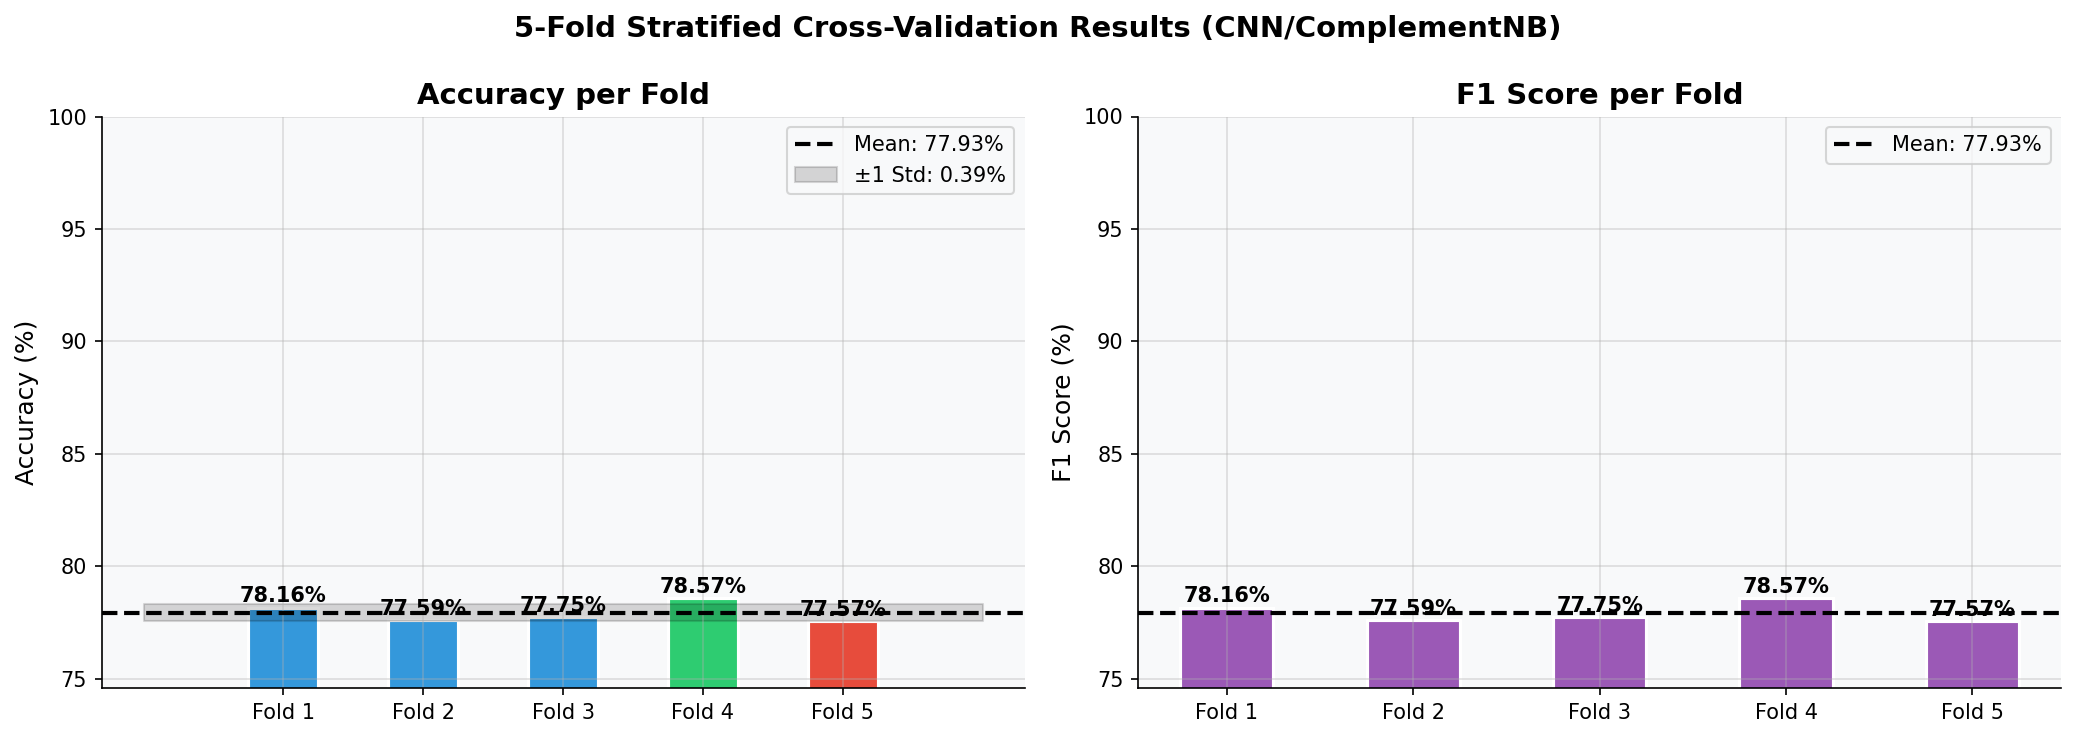

✅ Cross-validation chart saved as 07_cross_validation.png


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 5-FOLD STRATIFIED CROSS-VALIDATION
# Pipeline: char_wb TF-IDF → ComplementNB (CNN) — best single NB model for CV
# 🔧 TUNING: Increase n_splits to 10 for more reliable estimate (slower)
# ─────────────────────────────────────────────────────────────────────────────
print('🔁 Running 5-Fold Cross-Validation (this may take a few minutes)...')

cv_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                               max_features=150_000, sublinear_tf=True, min_df=2)),
    ('clf',   ComplementNB(alpha=CNN_ALPHA))
])

X_cv = pd.concat([X_raw_train, X_raw_val]).reset_index(drop=True)
y_cv = np.concatenate([y_train, y_val])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_acc = cross_val_score(cv_pipe, X_cv, y_cv, cv=skf,
                          scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(cv_pipe, X_cv, y_cv, cv=skf,
                          scoring='f1_weighted', n_jobs=-1)

print(f'\nCross-Validation Results (5-Fold, CNN/ComplementNB):')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'  Per-fold accuracy: {[f"{v:.4f}" for v in cv_acc]}')

# CV Results chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5-Fold Stratified Cross-Validation Results (CNN/ComplementNB)',
             fontweight='bold', fontsize=14)

fold_labels = [f'Fold {i+1}' for i in range(5)]

ax = axes[0]
bar_colors = ['#E74C3C' if v == cv_acc.min() else
              '#2ECC71' if v == cv_acc.max() else '#3498DB'
              for v in cv_acc]
bars = ax.bar(fold_labels, cv_acc * 100, color=bar_colors,
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cv_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val*100:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.axhline(y=cv_acc.mean()*100, color='black', linestyle='--',
           lw=2, label=f'Mean: {cv_acc.mean()*100:.2f}%')
ax.fill_between(range(-1, 6),
                (cv_acc.mean() - cv_acc.std()) * 100,
                (cv_acc.mean() + cv_acc.std()) * 100,
                alpha=0.15, color='black', label=f'±1 Std: {cv_acc.std()*100:.2f}%')
ymin_cv = max(70, cv_acc.min()*100 - 3)
ax.set_ylim(ymin_cv, 100)
ax.set_title('Accuracy per Fold', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.legend()

ax = axes[1]
bars = ax.bar(fold_labels, cv_f1 * 100, color='#9B59B6',
              width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cv_f1):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val*100:.2f}%', ha='center', va='bottom',
            fontweight='bold', fontsize=10)
ax.axhline(y=cv_f1.mean()*100, color='black', linestyle='--',
           lw=2, label=f'Mean: {cv_f1.mean()*100:.2f}%')
ymin_f1cv = max(70, cv_f1.min()*100 - 3)
ax.set_ylim(ymin_f1cv, 100)
ax.set_title('F1 Score per Fold', fontweight='bold')
ax.set_ylabel('F1 Score (%)')
ax.legend()

plt.tight_layout()
plt.savefig('07_cross_validation.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Cross-validation chart saved as 07_cross_validation.png')

## 📈 Cell 13 — Learning Curve

Learning curves show whether the model is **overfitting** or **underfitting**:
- **Large gap** between train and val → Overfitting → Increase alpha, reduce features
- **Both curves low** → Underfitting → Decrease alpha, increase features/ngram range
- **Curves converging** → Good fit

📈 Computing learning curves (takes a few minutes)...


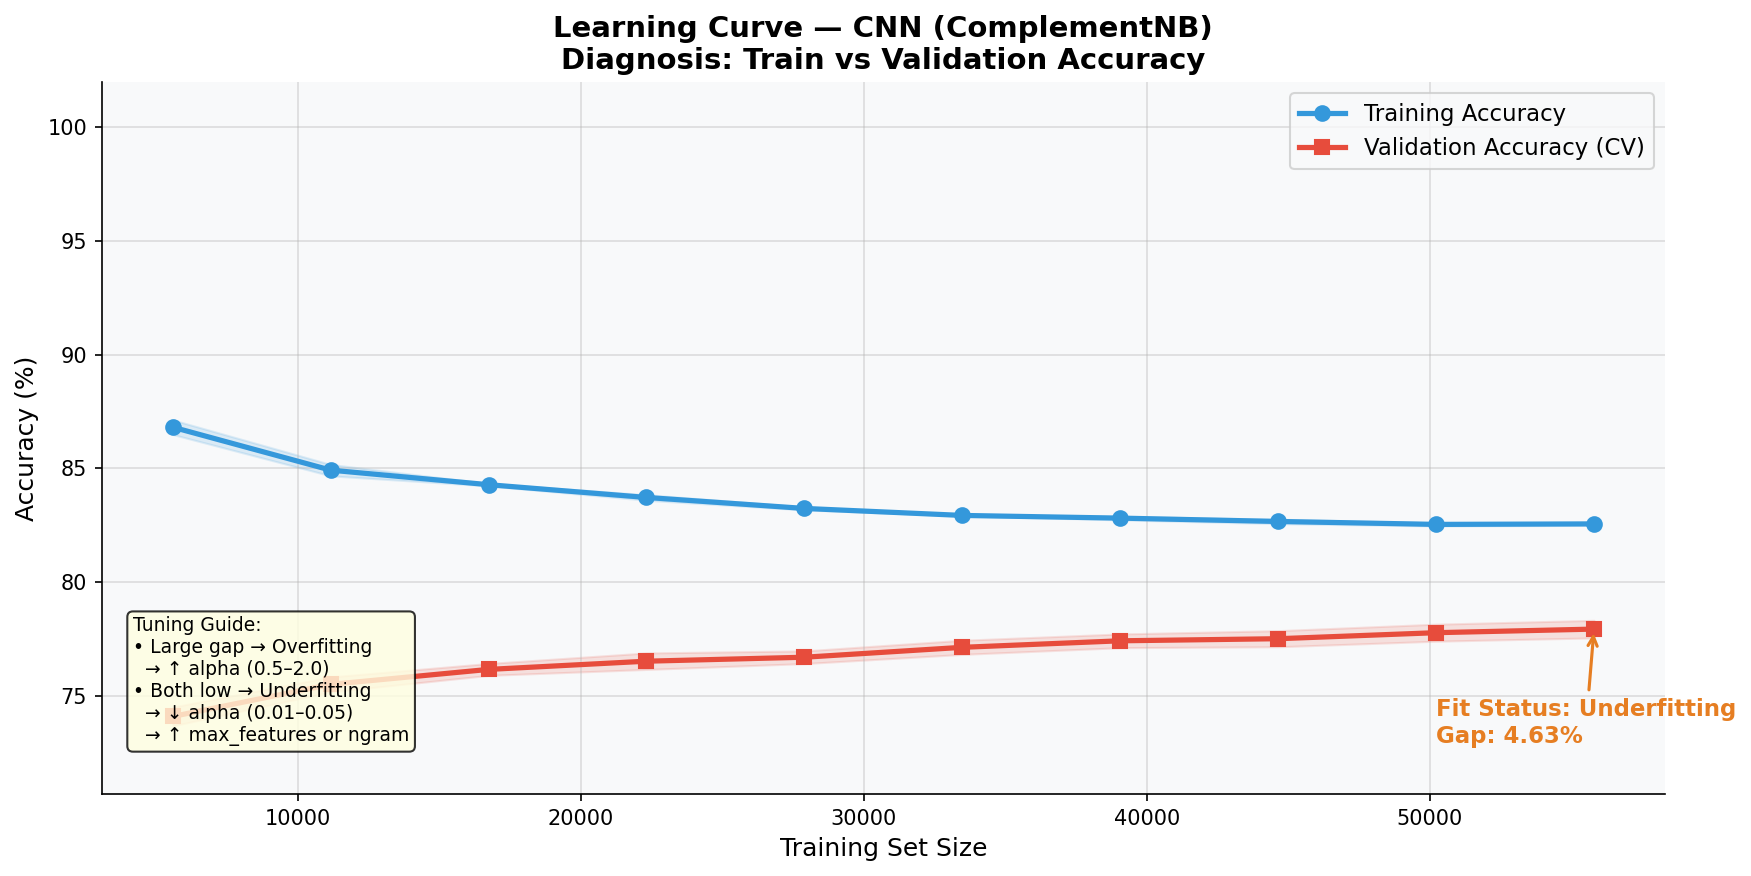

✅ Learning curve saved as 08_learning_curve.png
   Final train accuracy: 82.56%
   Final val accuracy  : 77.93%
   Gap (overfit signal): 4.63%
   Diagnosis: Underfitting


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# LEARNING CURVE
# Diagnoses overfitting / underfitting across training set sizes
# 🔧 INTERPRETING THE CURVE:
#   - Large train-val gap → Overfitting → increase alpha or reduce max_features
#   - Both curves plateauing low → Underfitting → decrease alpha or expand ngram_range
#   - Curves converging → Good generalization
# ─────────────────────────────────────────────────────────────────────────────
print('📈 Computing learning curves (takes a few minutes)...')

lc_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                               max_features=150_000, sublinear_tf=True, min_df=2)),
    ('clf',   ComplementNB(alpha=CNN_ALPHA))
])

train_sizes, train_scores, val_scores = learning_curve(
    lc_pipe,
    X_cv, y_cv,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(train_sizes, train_mean * 100, 'o-', color='#3498DB',
        lw=2.5, ms=7, label='Training Accuracy')
ax.fill_between(train_sizes,
                (train_mean - train_std) * 100,
                (train_mean + train_std) * 100,
                alpha=0.15, color='#3498DB')

ax.plot(train_sizes, val_mean * 100, 's-', color='#E74C3C',
        lw=2.5, ms=7, label='Validation Accuracy (CV)')
ax.fill_between(train_sizes,
                (val_mean - val_std) * 100,
                (val_mean + val_std) * 100,
                alpha=0.15, color='#E74C3C')

gap = train_mean[-1] - val_mean[-1]
status = 'Overfitting' if gap > 0.05 else ('Underfitting' if val_mean[-1] < 0.80 else 'Good Fit')
status_color = '#E74C3C' if status == 'Overfitting' else ('#E67E22' if status == 'Underfitting' else '#2ECC71')

ax.annotate(f'Fit Status: {status}\nGap: {gap*100:.2f}%',
            xy=(train_sizes[-1], val_mean[-1]*100),
            xytext=(train_sizes[-2], (val_mean[-1]-0.05)*100),
            fontsize=11, fontweight='bold', color=status_color,
            arrowprops=dict(arrowstyle='->', color=status_color, lw=1.5))

ymin_lc = max(60, (val_mean.min() - val_std.max())*100 - 3)
ax.set_ylim(ymin_lc, 102)
ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Learning Curve — CNN (ComplementNB)\nDiagnosis: Train vs Validation Accuracy',
             fontweight='bold')
ax.legend(fontsize=11)

# Add tuning instructions as text box
tuning_text = (
    'Tuning Guide:\n'
    '• Large gap → Overfitting\n'
    '  → ↑ alpha (0.5–2.0)\n'
    '• Both low → Underfitting\n'
    '  → ↓ alpha (0.01–0.05)\n'
    '  → ↑ max_features or ngram'
)
ax.text(0.02, 0.25, tuning_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('08_learning_curve.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'✅ Learning curve saved as 08_learning_curve.png')
print(f'   Final train accuracy: {train_mean[-1]*100:.2f}%')
print(f'   Final val accuracy  : {val_mean[-1]*100:.2f}%')
print(f'   Gap (overfit signal): {gap*100:.2f}%')
print(f'   Diagnosis: {status}')

## 🔍 Cell 14 — Hyperparameter Sensitivity Analysis

🔍 Analyzing alpha parameter sensitivity (CNN/ComplementNB)...
  alpha= 0.001: Train=0.8428  Val=0.7795
  alpha= 0.005: Train=0.8382  Val=0.7786
  alpha=  0.01: Train=0.8358  Val=0.7782
  alpha=  0.05: Train=0.8271  Val=0.7760
  alpha=   0.1: Train=0.8217  Val=0.7748
  alpha=   0.3: Train=0.8119  Val=0.7728
  alpha=   0.5: Train=0.8059  Val=0.7706
  alpha=   1.0: Train=0.7971  Val=0.7653
  alpha=   2.0: Train=0.7870  Val=0.7601
  alpha=   5.0: Train=0.7724  Val=0.7541

🔍 Analyzing KNN k sensitivity...
  k=  1: Val=0.7099
  k=  3: Val=0.7284
  k=  5: Val=0.7410
  k=  7: Val=0.7481
  k=  9: Val=0.7523
  k= 11: Val=0.7575
  k= 15: Val=0.7648
  k= 21: Val=0.7678


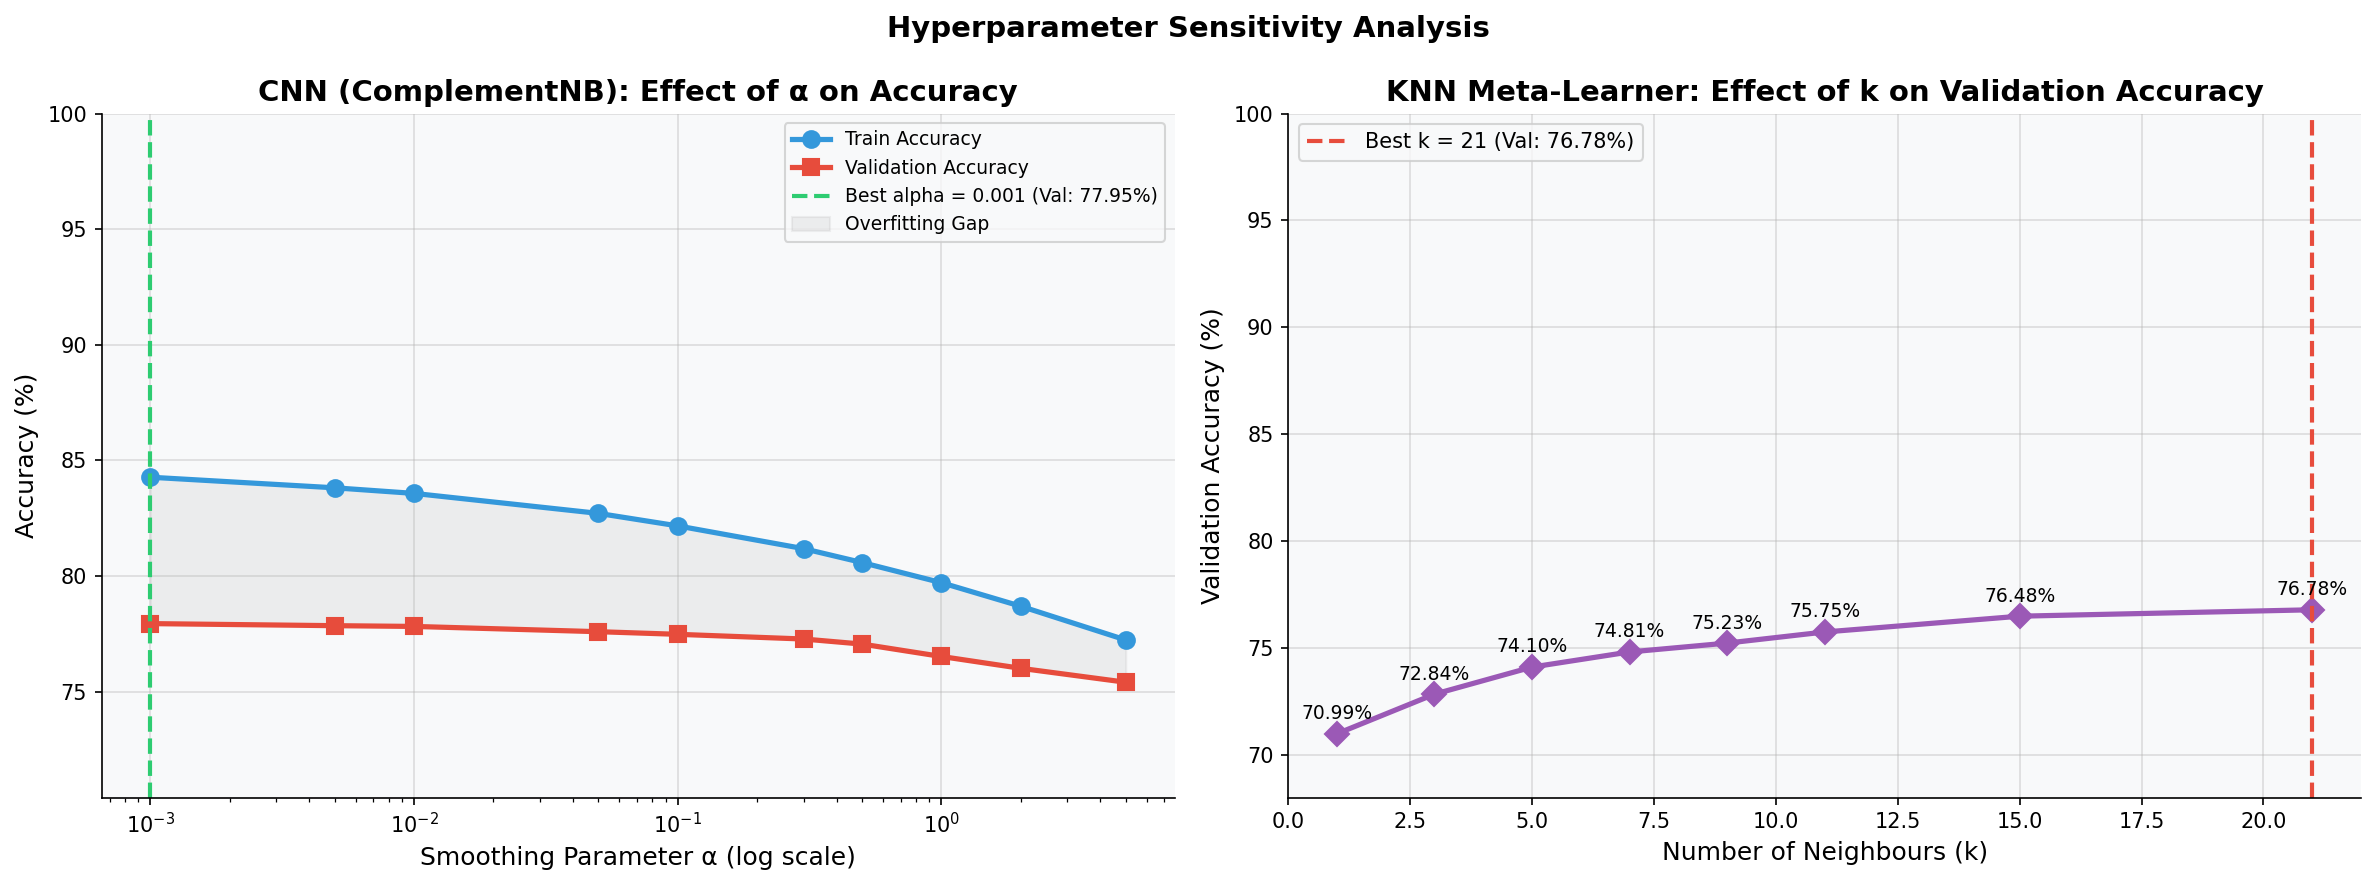


✅ Best alpha = 0.001 | Validation Accuracy = 77.95%
   Best k     = 21     | Validation Accuracy = 76.78%
✅ Hyperparameter chart saved as 09_hyperparameter_analysis.png

🔧 To use best params: set CNN_ALPHA=0.001, KNN_K=21 in Cell 7 and re-run


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# HYPERPARAMETER ANALYSIS
# Effect of alpha (smoothing) on CNN (ComplementNB) performance
# 🔧 TUNING: Best alpha from this chart should be set as CNN_ALPHA in Cell 7
# ─────────────────────────────────────────────────────────────────────────────
print('🔍 Analyzing alpha parameter sensitivity (CNN/ComplementNB)...')

alpha_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
train_accs_hp, val_accs_hp = [], []

vec_hp = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5),
                          max_features=100_000, sublinear_tf=True, min_df=2)
X_tr_hp = vec_hp.fit_transform(X_raw_train)
X_vl_hp = vec_hp.transform(X_raw_val)

for alpha in alpha_values:
    clf_hp = ComplementNB(alpha=alpha)
    clf_hp.fit(X_tr_hp, y_train)
    train_accs_hp.append(accuracy_score(y_train, clf_hp.predict(X_tr_hp)))
    val_accs_hp.append(accuracy_score(y_val,   clf_hp.predict(X_vl_hp)))
    print(f'  alpha={alpha:>6}: Train={train_accs_hp[-1]:.4f}  Val={val_accs_hp[-1]:.4f}')

# Also: KNN k sensitivity
print('\n🔍 Analyzing KNN k sensitivity...')
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
k_val_accs = []
for k in k_values:
    knn_test_k = KNeighborsClassifier(n_neighbors=k, weights='distance',
                                       metric=KNN_METRIC, n_jobs=-1)
    knn_test_k.fit(oof_train_meta, y_train)
    k_val_accs.append(accuracy_score(y_val, knn_test_k.predict(val_meta)))
    print(f'  k={k:>3}: Val={k_val_accs[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Hyperparameter Sensitivity Analysis', fontweight='bold', fontsize=14)

# Alpha sensitivity
ax = axes[0]
ax.semilogx(alpha_values, [v*100 for v in train_accs_hp], 'o-',
            color='#3498DB', lw=2.5, ms=8, label='Train Accuracy')
ax.semilogx(alpha_values, [v*100 for v in val_accs_hp], 's-',
            color='#E74C3C', lw=2.5, ms=8, label='Validation Accuracy')
best_alpha = alpha_values[np.argmax(val_accs_hp)]
best_val_hp = max(val_accs_hp) * 100
ax.axvline(x=best_alpha, color='#2ECC71', linestyle='--', lw=2,
           label=f'Best alpha = {best_alpha} (Val: {best_val_hp:.2f}%)')
ax.fill_between(alpha_values,
                [v*100 for v in val_accs_hp],
                [v*100 for v in train_accs_hp],
                alpha=0.1, color='gray', label='Overfitting Gap')
ax.set_xlabel('Smoothing Parameter α (log scale)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('CNN (ComplementNB): Effect of α on Accuracy', fontweight='bold')
ax.legend(fontsize=9)
ymin_hp = max(60, min(val_accs_hp)*100 - 5)
ax.set_ylim(ymin_hp, 100)

# KNN k sensitivity
ax = axes[1]
ax.plot(k_values, [v*100 for v in k_val_accs], 'D-',
        color='#9B59B6', lw=2.5, ms=8)
best_k = k_values[np.argmax(k_val_accs)]
best_k_acc = max(k_val_accs) * 100
ax.axvline(x=best_k, color='#E74C3C', linestyle='--', lw=2,
           label=f'Best k = {best_k} (Val: {best_k_acc:.2f}%)')
for k, v in zip(k_values, k_val_accs):
    ax.annotate(f'{v*100:.2f}%', xy=(k, v*100), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=9)
ax.set_xlabel('Number of Neighbours (k)', fontsize=12)
ax.set_ylabel('Validation Accuracy (%)', fontsize=12)
ax.set_title('KNN Meta-Learner: Effect of k on Validation Accuracy', fontweight='bold')
ax.legend(fontsize=10)
ymin_k = max(60, min(k_val_accs)*100 - 3)
ax.set_ylim(ymin_k, 100)

plt.tight_layout()
plt.savefig('09_hyperparameter_analysis.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'\n✅ Best alpha = {best_alpha} | Validation Accuracy = {best_val_hp:.2f}%')
print(f'   Best k     = {best_k}     | Validation Accuracy = {best_k_acc:.2f}%')
print('✅ Hyperparameter chart saved as 09_hyperparameter_analysis.png')
print(f'\n🔧 To use best params: set CNN_ALPHA={best_alpha}, KNN_K={best_k} in Cell 7 and re-run')

## 🏆 Cell 15 — Final Metrics Dashboard

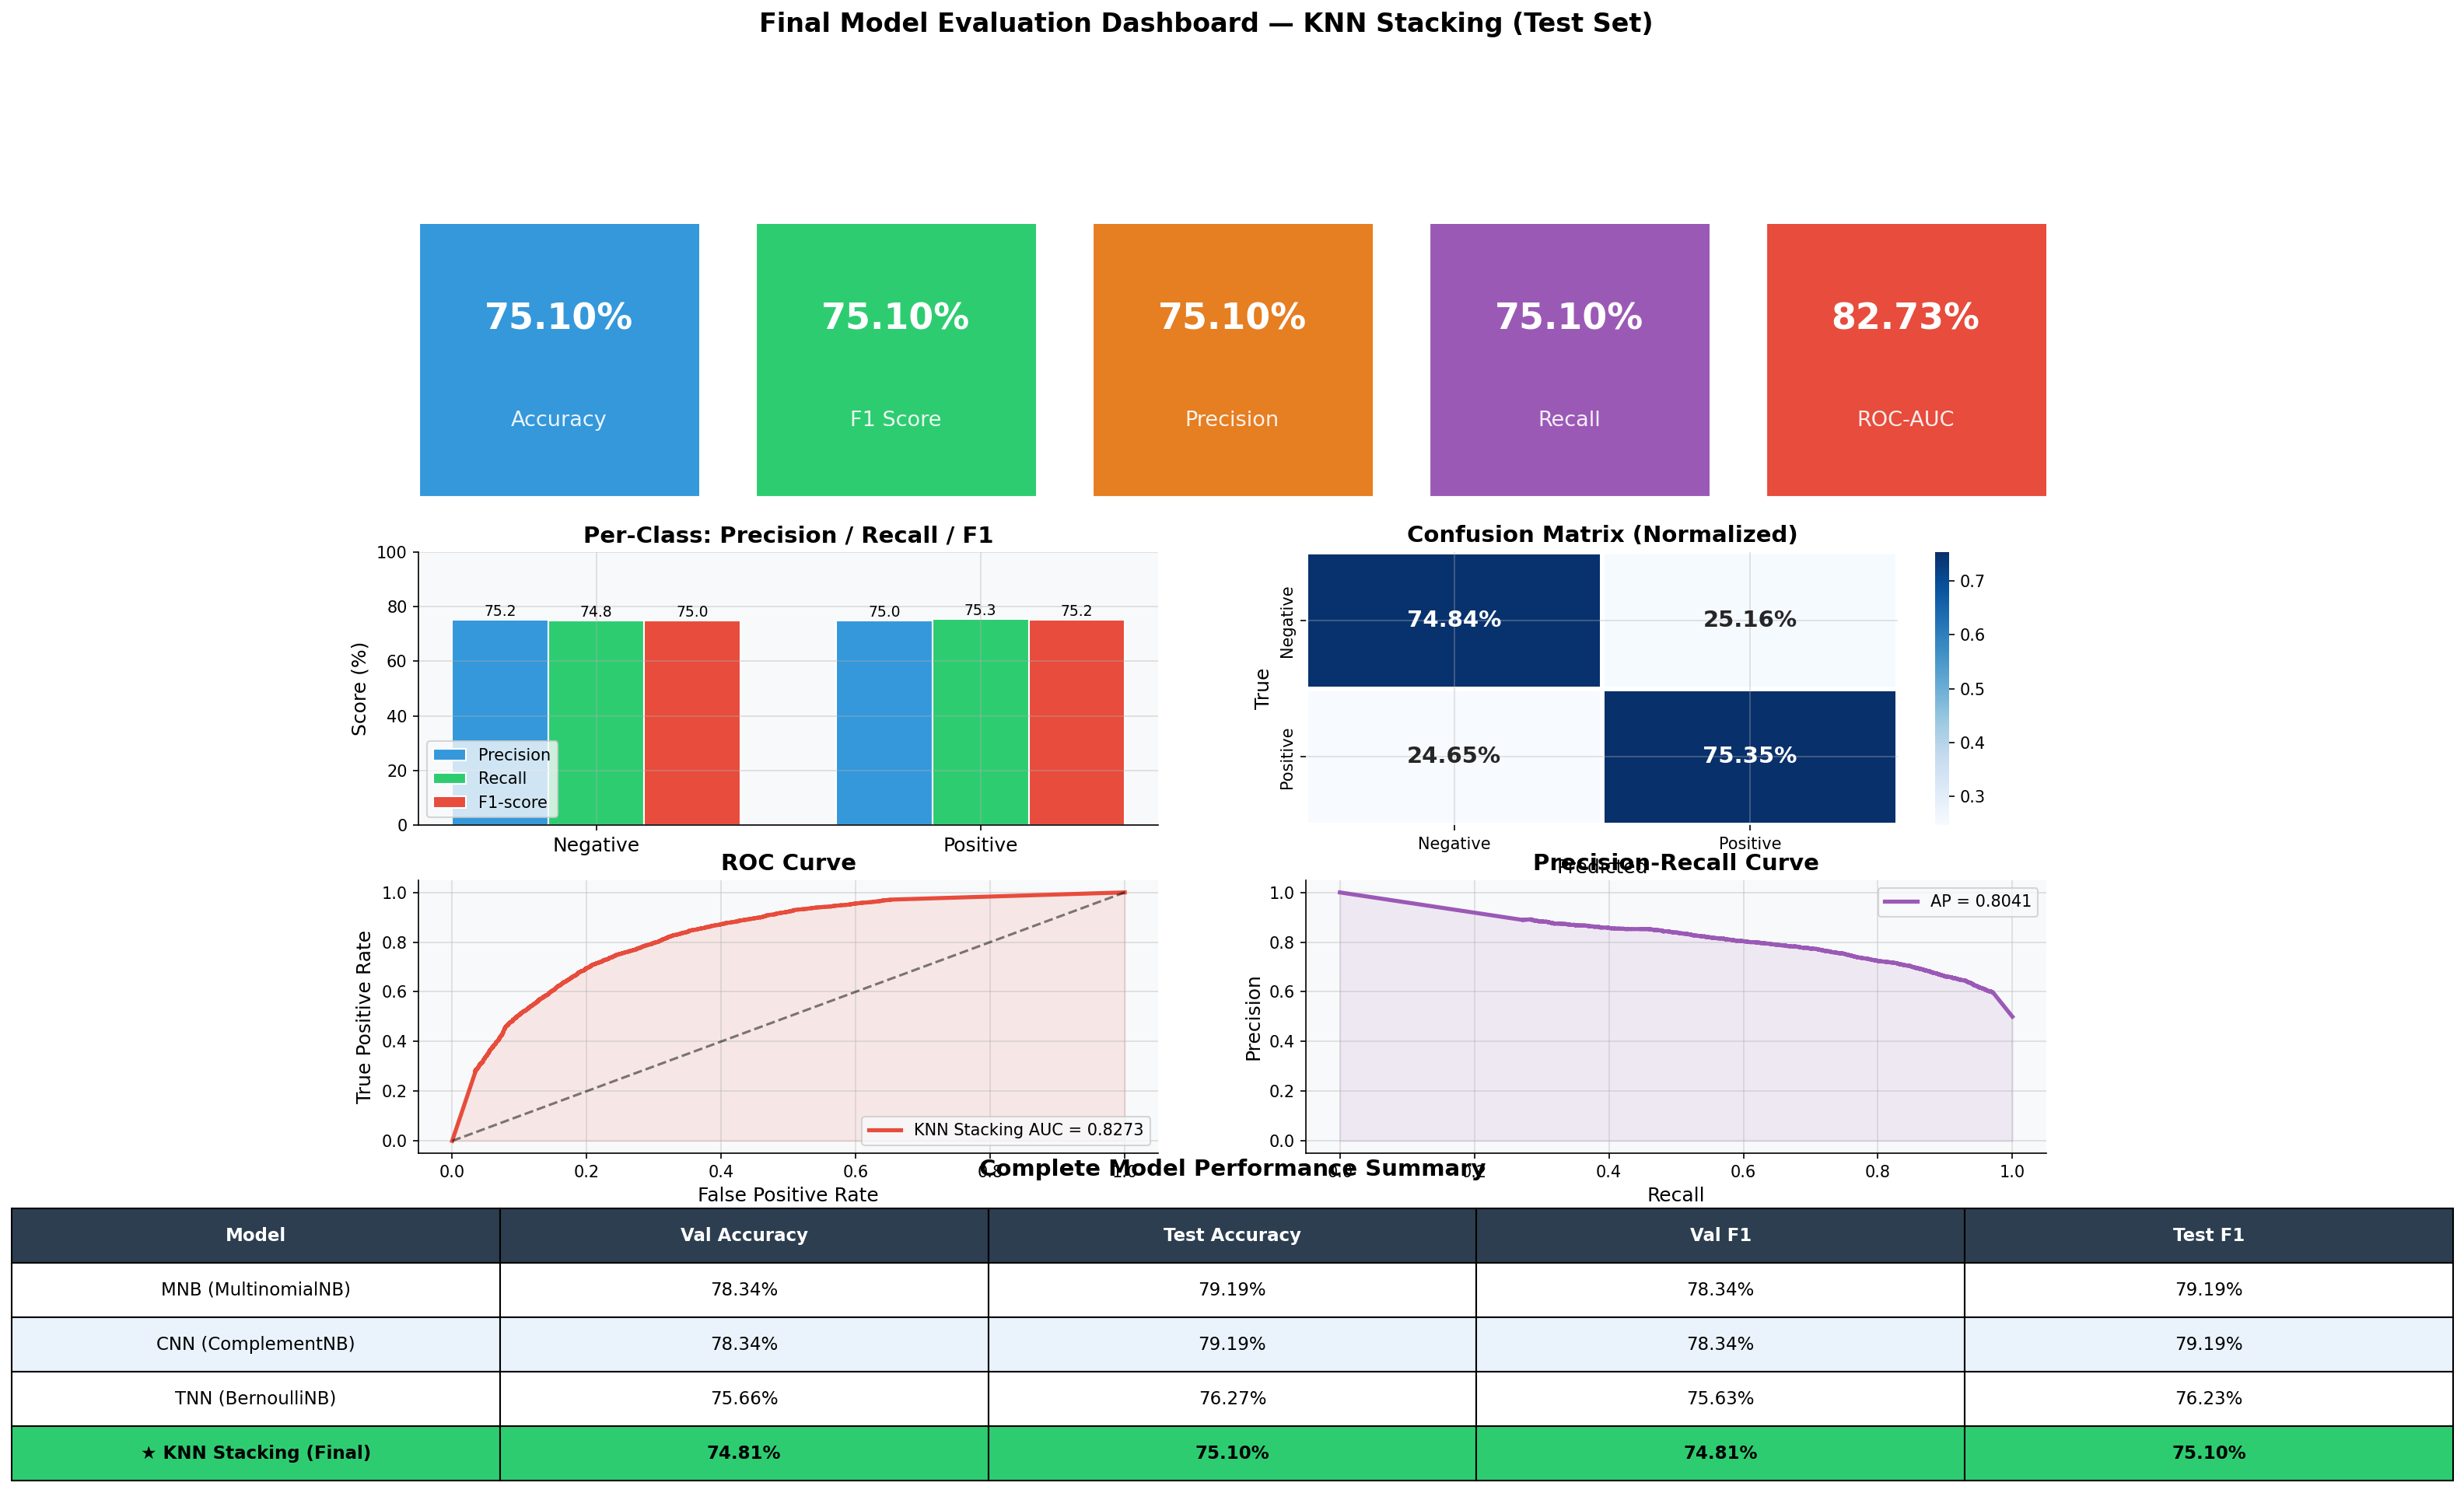

✅ Final dashboard saved as 10_final_dashboard.png


In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPREHENSIVE FINAL METRICS DASHBOARD
# ─────────────────────────────────────────────────────────────────────────────

report_dict = classification_report(y_test, y_pred,
                                     target_names=le.classes_,
                                     output_dict=True)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Final Model Evaluation Dashboard — KNN Stacking (Test Set)',
             fontsize=16, fontweight='bold', y=1.01)

# ── Row 1: Metric summary cards ──
metrics = [
    ('Accuracy',  test_acc,  '#3498DB'),
    ('F1 Score',  test_f1,   '#2ECC71'),
    ('Precision', test_prec, '#E67E22'),
    ('Recall',    test_rec,  '#9B59B6'),
    ('ROC-AUC',   test_auc,  '#E74C3C'),
]
for i, (name, val, color) in enumerate(metrics):
    ax = fig.add_subplot(4, 5, i + 1)
    ax.set_facecolor(color)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.text(0.5, 0.65, f'{val*100:.2f}%', ha='center', va='center',
            fontsize=22, fontweight='bold', color='white',
            transform=ax.transAxes)
    ax.text(0.5, 0.28, name, ha='center', va='center',
            fontsize=13, color='white', alpha=0.9,
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(2)

# ── Row 2 Left: Per-class metrics bar ──
ax2 = fig.add_subplot(4, 2, 3)
class_metrics = ['precision', 'recall', 'f1-score']
x_pos = np.arange(len(le.classes_))
width = 0.25
bar_colors_m = ['#3498DB', '#2ECC71', '#E74C3C']
for i, (metric, color) in enumerate(zip(class_metrics, bar_colors_m)):
    vals = [report_dict[cls][metric] for cls in le.classes_]
    bars = ax2.bar(x_pos + i*width, [v*100 for v in vals],
                   width, label=metric.capitalize(),
                   color=color, edgecolor='white', linewidth=1)
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val*100:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_xticks(x_pos + width)
ax2.set_xticklabels(le.classes_, fontsize=12)
ax2.set_ylim(0, 100)
ax2.set_title('Per-Class: Precision / Recall / F1', fontweight='bold')
ax2.set_ylabel('Score (%)')
ax2.legend()

# ── Row 2 Right: Confusion Matrix ──
ax3 = fig.add_subplot(4, 2, 4)
sns.heatmap(cm_norm, annot=True, fmt='.2%',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=ax3, linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax3.set_title('Confusion Matrix (Normalized)', fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

# ── Row 3 Left: ROC Curve ──
ax4 = fig.add_subplot(4, 2, 5)
fpr, tpr, _ = roc_curve(y_test, y_prob_pos)
ax4.plot(fpr, tpr, color='#E74C3C', lw=2.5,
         label=f'KNN Stacking AUC = {test_auc:.4f}')
ax4.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
ax4.fill_between(fpr, tpr, alpha=0.1, color='#E74C3C')
ax4.set_xlabel('False Positive Rate')
ax4.set_ylabel('True Positive Rate')
ax4.set_title('ROC Curve', fontweight='bold')
ax4.legend(loc='lower right')

# ── Row 3 Right: Precision-Recall Curve ──
ax5 = fig.add_subplot(4, 2, 6)
prec_c, rec_c, _ = precision_recall_curve(y_test, y_prob_pos)
ap = average_precision_score(y_test, y_prob_pos)
ax5.plot(rec_c, prec_c, color='#9B59B6', lw=2.5, label=f'AP = {ap:.4f}')
ax5.fill_between(rec_c, prec_c, alpha=0.1, color='#9B59B6')
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision-Recall Curve', fontweight='bold')
ax5.legend()

# ── Row 4: Full summary table ──
ax6 = fig.add_subplot(4, 1, 4)
ax6.axis('off')

mnb_test_preds = mnb_model.predict(X_test_main)
cnn_test_preds = cnn_model.predict(X_test_main)
tnn_test_preds = tnn_model.predict(X_test_bin)

summary_data = [
    ['MNB (MultinomialNB)',
     f'{mnb_val_acc*100:.2f}%', f'{accuracy_score(y_test, mnb_test_preds)*100:.2f}%',
     f'{mnb_val_f1*100:.2f}%', f'{f1_score(y_test, mnb_test_preds, average="weighted")*100:.2f}%'],
    ['CNN (ComplementNB)',
     f'{cnn_val_acc*100:.2f}%', f'{accuracy_score(y_test, cnn_test_preds)*100:.2f}%',
     f'{cnn_val_f1*100:.2f}%', f'{f1_score(y_test, cnn_test_preds, average="weighted")*100:.2f}%'],
    ['TNN (BernoulliNB)',
     f'{tnn_val_acc*100:.2f}%', f'{accuracy_score(y_test, tnn_test_preds)*100:.2f}%',
     f'{tnn_val_f1*100:.2f}%', f'{f1_score(y_test, tnn_test_preds, average="weighted")*100:.2f}%'],
    ['★ KNN Stacking (Final)',
     f'{knn_val_acc*100:.2f}%', f'{test_acc*100:.2f}%',
     f'{knn_val_f1*100:.2f}%', f'{test_f1*100:.2f}%'],
]
tbl = ax6.table(
    cellText=summary_data,
    colLabels=['Model', 'Val Accuracy', 'Test Accuracy', 'Val F1', 'Test F1'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.5, 2.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor(COLORS['primary'])
        cell.set_text_props(color='white', fontweight='bold')
    elif r == len(summary_data):
        cell.set_facecolor('#2ECC71')
        cell.set_text_props(fontweight='bold')
    else:
        cell.set_facecolor('#EAF2FB' if r % 2 == 0 else 'white')
ax6.set_title('Complete Model Performance Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('10_final_dashboard.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Final dashboard saved as 10_final_dashboard.png')

## 💡 Cell 16 — Error Analysis

Total test samples   : 12,311
Correctly classified : 9,245 (75.10%)
Misclassified        : 3,066 (24.90%)

Error breakdown:
true_label  pred_label
Negative    Positive      1549
Positive    Negative      1517
dtype: int64


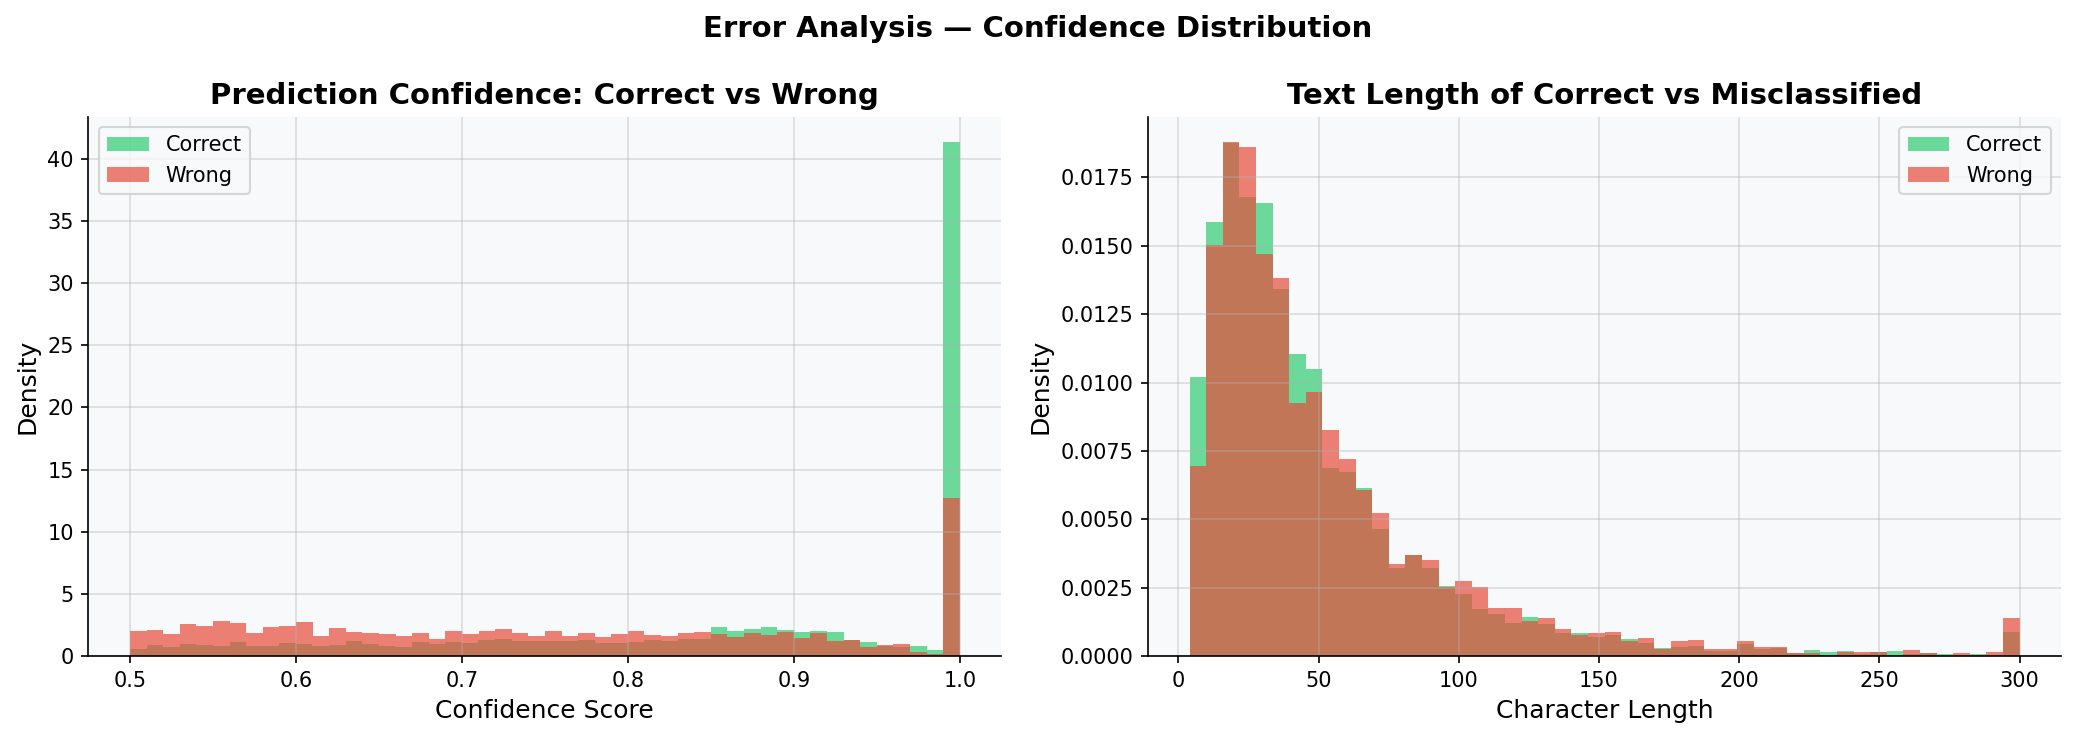


📋 Sample Misclassified Examples:
──────────────────────────────────────────────────────────────────────
Text      : ভাইয়া কেন বাবা বলতে পারছ না
True      : Negative | Predicted: Positive | Confidence: 1.000
──────────────────────────────────────────────────────────────────────
Text      : যাক শেষ পর্যন্ত মেঘলা মামনি   হতে পারল না
True      : Positive | Predicted: Negative | Confidence: 1.000
──────────────────────────────────────────────────────────────────────
Text      : ভাইজান, এই ভিডিওর লিংকটা দিবেন প্লীজ। অনেক কাজে আসবে ।
True      : Positive | Predicted: Negative | Confidence: 0.763
──────────────────────────────────────────────────────────────────────
Text      : ভিডিওটা তখন দেখছি যখন কিনা ব্রাজিল পেয়েছে ফ্লাইটের টিকিট এবং আর্জেন্টিনা পেয়েছে 
True      : Negative | Predicted: Positive | Confidence: 0.954
──────────────────────────────────────────────────────────────────────
Text      : ভাই নাসির আর তামিমাকে নিয়ে ভিডিও দেন।।
True      : Positive | Predicted: Negative | Confidenc

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# ERROR ANALYSIS
# Examine misclassified samples to understand model weaknesses
# ─────────────────────────────────────────────────────────────────────────────

test_idx = X_raw_test.index
test_df  = df.loc[test_idx].copy().reset_index(drop=True)
test_df['y_true']      = y_test
test_df['y_pred']      = y_pred
test_df['confidence']  = knn_meta.predict_proba(test_meta).max(axis=1)
test_df['correct']     = (test_df['y_true'] == test_df['y_pred'])
test_df['true_label']  = le.inverse_transform(y_test)
test_df['pred_label']  = le.inverse_transform(y_pred)

errors = test_df[~test_df['correct']]

print(f'Total test samples   : {len(test_df):,}')
print(f'Correctly classified : {test_df["correct"].sum():,} ({test_df["correct"].mean()*100:.2f}%)')
print(f'Misclassified        : {len(errors):,} ({len(errors)/len(test_df)*100:.2f}%)')

print('\nError breakdown:')
print(errors.groupby(['true_label', 'pred_label']).size())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis — Confidence Distribution', fontweight='bold', fontsize=14)

ax = axes[0]
ax.hist(test_df[test_df['correct']]['confidence'], bins=50,
        color='#2ECC71', alpha=0.7, density=True, label='Correct')
ax.hist(test_df[~test_df['correct']]['confidence'], bins=50,
        color='#E74C3C', alpha=0.7, density=True, label='Wrong')
ax.set_title('Prediction Confidence: Correct vs Wrong', fontweight='bold')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Density')
ax.legend()

ax = axes[1]
error_lengths   = errors['Comment '].str.len().clip(upper=300)
correct_lengths = test_df[test_df['correct']]['Comment '].str.len().clip(upper=300)
ax.hist(correct_lengths, bins=50, color='#2ECC71', alpha=0.7,
        density=True, label='Correct')
ax.hist(error_lengths, bins=50, color='#E74C3C', alpha=0.7,
        density=True, label='Wrong')
ax.set_title('Text Length of Correct vs Misclassified', fontweight='bold')
ax.set_xlabel('Character Length')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig('11_error_analysis.png', bbox_inches='tight', dpi=300)
plt.show()

print('\n📋 Sample Misclassified Examples:')
print('─' * 70)
for _, row in errors.sample(min(5, len(errors)), random_state=42).iterrows():
    print(f"Text      : {row['Comment '][:80]}")
    print(f"True      : {row['true_label']} | Predicted: {row['pred_label']} | Confidence: {row['confidence']:.3f}")
    print('─' * 70)

print('\n✅ Error analysis saved as 11_error_analysis.png')

## 📝 Cell 17 — Final Summary Report

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# PRINT FINAL SUMMARY FOR THESIS
# ─────────────────────────────────────────────────────────────────────────────

print('=' * 65)
print('  THESIS FINAL RESULTS SUMMARY')
print('  Bangla Sports Sentiment Analysis')
print('  MNB + CNN + TNN → KNN Stacking Ensemble')
print('=' * 65)
print(f'\n  Dataset         : Bangla Sports Sentiment Dataset')
print(f'  Total Samples   : {len(df):,}')
print(f'  Classes         : Positive / Negative (Binary)')
print(f'  Class Balance   : {df["Category"].value_counts().to_dict()}')
print(f'\n  Split           : 70% Train / 15% Val / 15% Test')
print(f'  Train Samples   : {len(X_raw_train):,}')
print(f'  Val Samples     : {len(X_raw_val):,}')
print(f'  Test Samples    : {len(X_raw_test):,}')
print(f'\n  Feature Method  : TF-IDF Ensemble (char_wb + word n-grams + binary)')
print(f'  Main Features   : {total_features_main:,}  (MNB + CNN)')
print(f'  Binary Features : {total_features_bin:,}   (TNN)')
print(f'\n  Base Models     : MNB (MultinomialNB) + CNN (ComplementNB) + TNN (BernoulliNB)')
print(f'  Meta-Learner    : KNN (k={KNN_K}, metric={KNN_METRIC}, weights=distance)')
print(f'  Stacking Method : Out-of-Fold (5-fold) to prevent leakage')
print()
print(f'  ┌──────────────────────────────────────────────┐')
print(f'  │  TEST SET PERFORMANCE (Final / Unseen Data)  │')
print(f'  ├──────────────────────────────────────────────┤')
print(f'  │  Accuracy          : {test_acc*100:>6.2f}%               │')
print(f'  │  Weighted F1 Score : {test_f1*100:>6.2f}%               │')
print(f'  │  Precision         : {test_prec*100:>6.2f}%               │')
print(f'  │  Recall            : {test_rec*100:>6.2f}%               │')
print(f'  │  ROC-AUC           : {test_auc*100:>6.2f}%               │')
print(f'  └──────────────────────────────────────────────┘')
print()
print(f'  CV (5-Fold) Accuracy : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print(f'  CV (5-Fold) F1 Score : {cv_f1.mean()*100:.2f}% ± {cv_f1.std()*100:.2f}%')
print()
print('  Generated Charts:')
charts = [
    '01_eda_analysis.png           — EDA & Data Distribution',
    '02_dataset_split.png          — Train/Val/Test Split',
    '03_feature_engineering.png    — TF-IDF Feature Analysis',
    '04_model_comparison.png       — Model Accuracy & F1 Comparison',
    '05_confusion_matrix.png       — Confusion Matrix',
    '06_roc_pr_curves.png          — ROC & Precision-Recall Curves',
    '07_cross_validation.png       — 5-Fold Cross-Validation',
    '08_learning_curve.png         — Learning Curve (Overfit/Underfit Diagnosis)',
    '09_hyperparameter_analysis.png — Alpha & KNN-k Sensitivity',
    '10_final_dashboard.png        — Complete Metrics Dashboard',
    '11_error_analysis.png         — Error & Confidence Analysis',
]
for c in charts:
    print(f'  ✅ {c}')
print()
print('=' * 65)
print('\n🔧 QUICK TUNING REFERENCE:')
print('   To improve accuracy:')
print(f'   • Use best alpha from Cell 14: alpha={best_alpha}')
print(f'   • Use best k from Cell 14: k={best_k}')
print('   • Increase max_features to 200k in Cell 6')
print('   • Expand ngram_range to (2,6) in Cell 6')
print('   To reduce overfitting (if train >> val):')
print('   • Increase alpha values in Cell 7')
print('   • Increase KNN_K in Cell 7')
print('   To reduce underfitting (both low):')
print('   • Decrease alpha to 0.01')
print('   • Decrease KNN_K to 3 or 5')

  THESIS FINAL RESULTS SUMMARY
  Bangla Sports Sentiment Analysis
  MNB + CNN + TNN → KNN Stacking Ensemble

  Dataset         : Bangla Sports Sentiment Dataset
  Total Samples   : 82,073
  Classes         : Positive / Negative (Binary)
  Class Balance   : {'Negative': 41048, 'Positive': 41025}

  Split           : 70% Train / 15% Val / 15% Test
  Train Samples   : 57,451
  Val Samples     : 12,311
  Test Samples    : 12,311

  Feature Method  : TF-IDF Ensemble (char_wb + word n-grams + binary)
  Main Features   : 324,240  (MNB + CNN)
  Binary Features : 57,520   (TNN)

  Base Models     : MNB (MultinomialNB) + CNN (ComplementNB) + TNN (BernoulliNB)
  Meta-Learner    : KNN (k=7, metric=euclidean, weights=distance)
  Stacking Method : Out-of-Fold (5-fold) to prevent leakage

  ┌──────────────────────────────────────────────┐
  │  TEST SET PERFORMANCE (Final / Unseen Data)  │
  ├──────────────────────────────────────────────┤
  │  Accuracy          :  75.10%               │
  │  Weighted